# ML Project for MoML in Montreal 

### Multilayer Perceptron (MLP) Classifier applied to a set of compound with biological activity against
### tyrosine kinases.

In [87]:
pip install rdkit

Note: you may need to restart the kernel to use updated packages.


In [88]:
import pandas as pd
import numpy as np
from rdkit import Chem, DataStructs
from rdkit.Chem import AllChem
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import classification_report
import matplotlib.pyplot as plt
import seaborn as sns

In [89]:
# Loads the bioactivity data into a Pandas dataframe
bioactivity_data = pd.read_csv("Kinase_final_data.csv")
print(bioactivity_data.iloc[:,0:7])

      molecule_chembl_id                                   canonical_smiles  \
0          CHEMBL3648023  CCCCc1ccc(Nc2nnc3cc(-c4cc(OC)cc(OC)c4)cc(C)c3n...   
1           CHEMBL154969  CONC(=O)CCc1c(SSc2[nH]c3ccccc3c2CCC(=O)NOC)[nH...   
2           CHEMBL507058              COc1cc(O)c2c(c1)-c1cc(O)c(O)cc1COC2=O   
3          CHEMBL3401367        COc1cccc(-c2nc3c(O)nc(NC(C)=O)nc3[nH]2)c1OC   
4          CHEMBL3681299  Cc1nc2cc(-n3ncc(C(=O)c4cc5cc(C(C)(C)C)ccc5[nH]...   
...                  ...                                                ...   
21436      CHEMBL3360610  C#Cc1cccc(Nc2ncnc3cc(OCCCCCCn4ccnc4[N+](=O)[O-...   
21437      CHEMBL1269735                          OCCNc1ncnc2sc3c(c12)CCCC3   
21438      CHEMBL1276317        O=C1Nc2ccccc2/C1=C1/Nc2ccccc2/C1=N\OCC(O)CO   
21439       CHEMBL604483  COc1cc2c(Oc3ccc(-c4nc5ccccc5s4)cc3F)ncnc2cc1OC...   
21440        CHEMBL25425     COc1cc2c(Nc3ccc(Cl)cc3F)ncnc2cc1OCCC1CCN(C)CC1   

       standard_value         class       MW     Lo

In [90]:
bioactivity_data.describe()

,standard_value,MW,LogP,NumHDonors,NumHAcceptors,pIC50
count,2.144100e+04,21441.000000,21441.000000,21441.000000,21441.000000,21441.000000
mean,1.569319e+05,457.727912,4.315861,2.103680,6.502355,6.445481
std,1.475192e+07,125.533487,1.553531,1.607012,2.215239,1.527983
min,5.010000e-09,90.034000,-11.854300,0.000000,0.000000,0.000000
25%,2.200000e+01,376.847000,3.403800,1.000000,5.000000,5.070581
50%,3.710000e+02,454.534000,4.326000,2.000000,6.000000,6.430626
75%,8.500000e+03,524.452000,5.252600,3.000000,8.000000,7.657577
max,2.120000e+09,2554.545000,13.028900,37.000000,36.000000,17.299989


In [91]:
# Converts the SMILES strings to RDKit molecules
molecules = [Chem.MolFromSmiles(smiles) for smiles 
             in bioactivity_data['canonical_smiles']]

# Generates the Morgan fingerprints for each molecule
fingerprints = [Chem.RDKFingerprint(molecule) for molecule in molecules]

# Converts the bioactivity data to binary classification labels
labels = [1 if bioactivity >= 6 else 0 for bioactivity in bioactivity_data['pIC50']]

In [92]:
# Count the occurrences of each class (active/inactive)
labels_counts = labels.count(1), labels.count(0)

# Print the counts
print("Number of active and inactive compounds:")
print(labels_counts)

Number of active and inactive compounds:
(13062, 8379)


In [93]:
# Standardize the input features
scaler = StandardScaler()
fingerprints_scaled = scaler.fit_transform(fingerprints)

In [94]:
# Train the neural network model
model = MLPClassifier(hidden_layer_sizes=(100, 50, 25), activation='relu', alpha=0.001, solver='adam',
                      learning_rate='constant', max_iter=200, batch_size='auto', learning_rate_init=0.001,
                      shuffle=True, random_state=101, tol=1e-4, verbose=True, warm_start=False,
                      early_stopping=True, validation_fraction=0.1, n_iter_no_change=10)

In [95]:
# Perform cross-validation and get the scores
cv_scores = cross_val_score(model, fingerprints_scaled, labels, cv=5)

# Print the cross-validation scores
print("Cross-validation scores:", cv_scores)
print("Average cross-validation score:", np.mean(cv_scores))

Iteration 1, loss = 0.45604993
Validation score: 0.842657
Iteration 2, loss = 0.33607915
Validation score: 0.851399
Iteration 3, loss = 0.29173121
Validation score: 0.847319
Iteration 4, loss = 0.26616278
Validation score: 0.845571
Iteration 5, loss = 0.24530800
Validation score: 0.846737
Iteration 6, loss = 0.23363108
Validation score: 0.853147
Iteration 7, loss = 0.21698847
Validation score: 0.849650
Iteration 8, loss = 0.20500159
Validation score: 0.855478
Iteration 9, loss = 0.19466602
Validation score: 0.833916
Iteration 10, loss = 0.18745086
Validation score: 0.849068
Iteration 11, loss = 0.18301408
Validation score: 0.849068
Iteration 12, loss = 0.17512423
Validation score: 0.837413
Iteration 13, loss = 0.17291152
Validation score: 0.831585
Iteration 14, loss = 0.16860759
Validation score: 0.841492
Iteration 15, loss = 0.16385977
Validation score: 0.841492
Iteration 16, loss = 0.15241339
Validation score: 0.845571
Iteration 17, loss = 0.15196899
Validation score: 0.844988
Iterat

In [ ]:
# Splits the data into training and testing sets (80/20 ratio)
X_train, X_test, y_train, y_test = train_test_split(fingerprints, 
                                            labels, test_size=0.25, random_state=101)
# Train the model on the training set
model.fit(X_train, y_train)

Iteration 1, loss = 0.53271360
Validation score: 0.787296
Iteration 2, loss = 0.43543754
Validation score: 0.812354
Iteration 3, loss = 0.38989522
Validation score: 0.810023
Iteration 4, loss = 0.36512300
Validation score: 0.824009
Iteration 5, loss = 0.34377162
Validation score: 0.809441
Iteration 6, loss = 0.32356384
Validation score: 0.798368
Iteration 7, loss = 0.31675226
Validation score: 0.809441
Iteration 8, loss = 0.30665451
Validation score: 0.736014
Iteration 9, loss = 0.29729031
Validation score: 0.804779
Iteration 10, loss = 0.28437879
Validation score: 0.831002
Iteration 11, loss = 0.27027696
Validation score: 0.835082
Iteration 12, loss = 0.25055602
Validation score: 0.844406
Iteration 13, loss = 0.24676375
Validation score: 0.833333
Iteration 14, loss = 0.24543465
Validation score: 0.837413
Iteration 15, loss = 0.22756768
Validation score: 0.834499
Iteration 16, loss = 0.22276404
Validation score: 0.830420
Iteration 17, loss = 0.22085512
Validation score: 0.828671
Iterat

MLPClassifier(alpha=0.001, early_stopping=True,
              hidden_layer_sizes=(100, 50, 25), random_state=101, verbose=True)

In [97]:
# Makes predictions on the testing set
y_pred = model.predict(X_test)

# Prints the classification report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.80      0.79      0.80      1680
           1       0.87      0.87      0.87      2609

    accuracy                           0.84      4289
   macro avg       0.83      0.83      0.83      4289
weighted avg       0.84      0.84      0.84      4289



In [98]:
# Calculate evaluation metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print('Accuracy:', accuracy)
print('Precision:', precision)
print('Recall:', recall)
print('F1 Score:', f1)

Accuracy: 0.840055957099557
Precision: 0.8676864244741874
Recall: 0.8696818704484477
F1 Score: 0.8686830015313936


In [99]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt
# Calculate the ROC curve and AUC
fpr, tpr, thresholds = roc_curve(y_test, y_pred)
auc = roc_auc_score(y_test, y_pred)

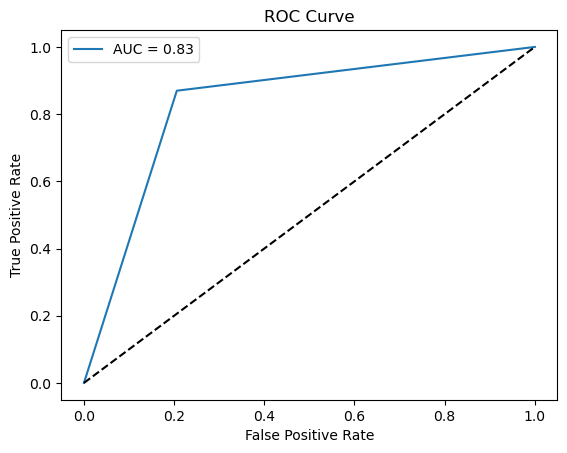

In [100]:
# Plot the ROC curve
plt.plot(fpr, tpr, label=f'AUC = {auc:.2f}')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()

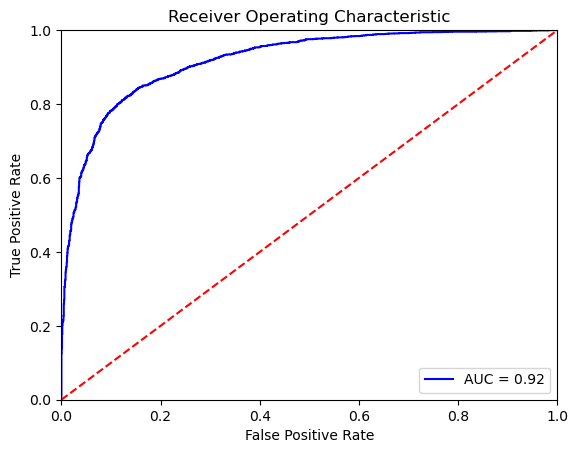

In [101]:
import sklearn.metrics as metrics
# calculate the fpr and tpr for all thresholds of the classification
probs = model.predict_proba(X_test)
preds = probs[:,1]
fpr, tpr, threshold = metrics.roc_curve(y_test, preds)
roc_auc = metrics.auc(fpr, tpr)

# plot the curve
import matplotlib.pyplot as plt
plt.title('Receiver Operating Characteristic')
plt.plot(fpr, tpr, 'b', label = 'AUC = %0.2f' % roc_auc)
plt.legend(loc = 'lower right')
plt.plot([0, 1], [0, 1],'r--')
plt.xlim([0, 1])
plt.ylim([0, 1])
plt.ylabel('True Positive Rate')
plt.xlabel('False Positive Rate')
plt.show()

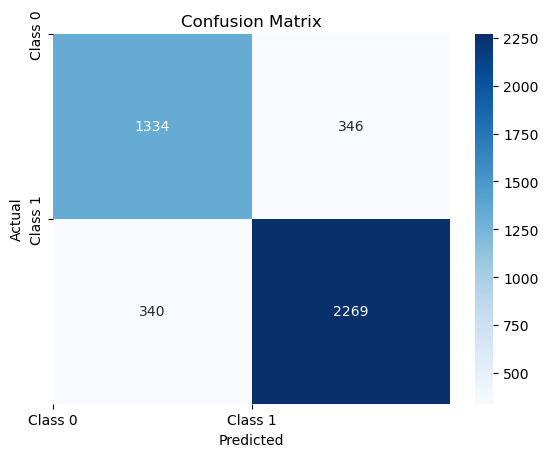

In [102]:
import seaborn as sns
from sklearn.metrics import confusion_matrix
# Create confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Create a list of class labels
class_labels = ['Class 0', 'Class 1']

# Plot confusion matrix as heatmap
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_labels, yticklabels=class_labels)

# Add labels, title, and ticks
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.xticks(np.arange(len(class_labels)), class_labels)
plt.yticks(np.arange(len(class_labels)), class_labels)

# Show the plot
plt.show()

# ML Proyect for MoML in Montreal 
### Gaussian Naive-Bayes (G-NB) Classifier applied to a set of compound with biological activity against tyrosine kinases.

In [1]:
import pandas as pd 
import seaborn as sns

# Loads the bioactivity data into a Pandas dataframe
bioactivity_data = pd.read_csv("ligands_descriptors_updated.csv", sep=';')
print(bioactivity_data.iloc[:,0:11])

                                                  SMILES   MolWt  LogP  HBD  \
0      CCCCc1ccc(Nc2nnc3cc(-c4cc(OC)cc(OC)c4)cc(C)c3n...  428.54  6.10    1   
1      CONC(=O)CCc1c(SSc2[nH]c3ccccc3c2CCC(=O)NOC)[nH...  498.63  4.67    4   
2                  COc1cc(O)c2c(c1)-c1cc(O)c(O)cc1COC2=O  288.26  2.15    3   
3            COc1cccc(-c2nc3c(O)nc(NC(C)=O)nc3[nH]2)c1OC  329.32  1.70    3   
4      Cc1nc2cc(-n3ncc(C(=O)c4cc5cc(C(C)(C)C)ccc5[nH]...  412.50  4.65    3   
...                                                  ...     ...   ...  ...   
21436  C#Cc1cccc(Nc2ncnc3cc(OCCCCCCn4ccnc4[N+](=O)[O-...  486.53  5.11    1   
21437                          OCCNc1ncnc2sc3c(c12)CCCC3  249.34  1.97    2   
21438        O=C1Nc2ccccc2/C1=C1/Nc2ccccc2/C1=N\OCC(O)CO  351.36  1.55    4   
21439  COc1cc2c(Oc3ccc(-c4nc5ccccc5s4)cc3F)ncnc2cc1OC...  559.67  5.86    0   
21440     COc1cc2c(Nc3ccc(Cl)cc3F)ncnc2cc1OCCC1CCN(C)CC1  444.94  5.29    1   

       HBA  RotatableBonds    TPSA  Volume  Lipinsk

In [2]:
#bioactivity_data.drop('molecule_chembl_id', axis=1, inplace=True)
#bioactivity_data.drop('canonical_smiles', axis=1, inplace=True)
#bioactivity_data.drop('standard_value', axis=1, inplace=True)
bioactivity_data.drop('SMILES', axis=1, inplace=True)

bioactivity_data.to_csv("dataset-processed.csv", index=False)
# Let's see what's in the Bank-full data - Jupyter notebooks print the result of the last thing you do
df = pd.read_csv("dataset-processed.csv")  

df.head()

,MolWt,LogP,HBD,HBA,RotatableBonds,TPSA,Volume,LipinskiViolations,NumAtoms,pIC50
0,428.54,6.10,1,6,8,69.16,257.96,1,32,4.000000
1,498.63,4.67,4,6,11,108.24,300.08,0,34,5.537602
2,288.26,2.15,3,6,1,96.22,173.53,0,21,8.000000
3,329.32,1.70,3,7,4,122.25,198.26,0,24,5.039529
4,412.50,4.65,3,5,3,105.38,248.31,0,31,6.823909


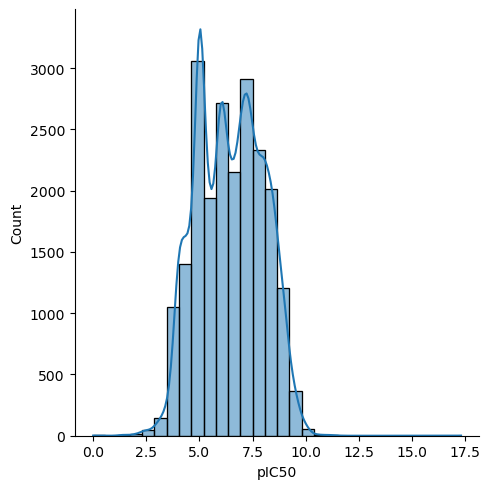

In [3]:
sns.displot(df['pIC50'], kde=True, bins=30)

In [247]:
print(df.iloc[:,0:10])

        MolWt  LogP  HBD  HBA  RotatableBonds    TPSA  Volume  \
0      428.54  6.10    1    6               8   69.16  257.96   
1      498.63  4.67    4    6              11  108.24  300.08   
2      288.26  2.15    3    6               1   96.22  173.53   
3      329.32  1.70    3    7               4  122.25  198.26   
4      412.50  4.65    3    5               3  105.38  248.31   
...       ...   ...  ...  ...             ...     ...     ...   
21436  486.53  5.11    1    9              12  117.23  292.89   
21437  249.34  1.97    2    5               3   58.04  150.06   
21438  351.36  1.55    4    6               4  103.18  211.52   
21439  559.67  5.86    0    9               9   72.84  336.87   
21440  444.94  5.29    1    6               7   59.51  267.57   

       LipinskiViolations  NumAtoms     pIC50  
0                       1        32  4.000000  
1                       0        34  5.537602  
2                       0        21  8.000000  
3                       0  

In [4]:
# Now we will check for missing values in the dataset
names = [] # list to store column names
values = [] # list to store number of missing values
def check_missing(df):
    if df.isnull().values.any() :
        print("There is missing in data")
        return True
    else:
        print("Data has no missing values")
        return False

if(check_missing(df)):
    for col_name in df.columns:
        if df[col_name].isnull().any() :
            #print(col_name + " column has "+str(df[col_name].isnull().sum())+" missing values")
            names.append(col_name)
            values.append(df[col_name].isnull().sum())
            
    missing = {"column":names,
              "# of missings":values}
    missingDf = pd.DataFrame(missing)
    print(missingDf)
    missingDf.plot.bar(x="column",y='# of missings', figsize=(6, 6),ylabel="# of missing",xlabel = "Column",color="red")


Data has no missing values


In [5]:
import random
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import LabelEncoder


In [6]:
# Converts the bioactivity data to binary classification labels

labels = ["True" if bioactivity >= 6 else "False" for bioactivity in bioactivity_data['pIC50']]

In [25]:
# We will split the dataset into training and testing sets 
X = df.drop("pIC50", axis=1)
y = labels

df.head()

,MolWt,LogP,HBD,HBA,RotatableBonds,TPSA,Volume,LipinskiViolations,NumAtoms,pIC50
0,428.54,6.10,1,6,8,69.16,257.96,1,32,4.000000
1,498.63,4.67,4,6,11,108.24,300.08,0,34,5.537602
2,288.26,2.15,3,6,1,96.22,173.53,0,21,8.000000
3,329.32,1.70,3,7,4,122.25,198.26,0,24,5.039529
4,412.50,4.65,3,5,3,105.38,248.31,0,31,6.823909


In [26]:
# Encoding the outcome column to get numerical class
le = LabelEncoder()
y = le.fit_transform(y)

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=101)


In [204]:
# Gaussian Naive Bayes classifier
gnb = GaussianNB()

# Train the classifier on the training data
gnb.fit(X_train, y_train)


GaussianNB()

In [205]:
# import performance metric libraries 
from sklearn.metrics import (
accuracy_score, 
confusion_matrix, 
ConfusionMatrixDisplay, 
f1_score, 
classification_report
)

In [206]:
# Make predictions on the testing data
y_pred = gnb.predict(X_test)

y_pred_train = gnb.predict(X_train)

# measure the performance
accuracy = accuracy_score(y_pred, y_test)
accuracy_train = accuracy_score(y_pred_train, y_train)
f1 = f1_score(y_pred, y_test, average="weighted") 
print("The accuracy of my Naive Bayes Model is:", accuracy) 
print("The accuracy of my Naive Bayes Model on training data is:", accuracy_train)
print("The F1 Score of my Naive Bayes Model is:", f1)

The accuracy of my Naive Bayes Model is: 0.6700242492072375
The accuracy of my Naive Bayes Model on training data is: 0.6680348258706468
The F1 Score of my Naive Bayes Model is: 0.6925531086202528


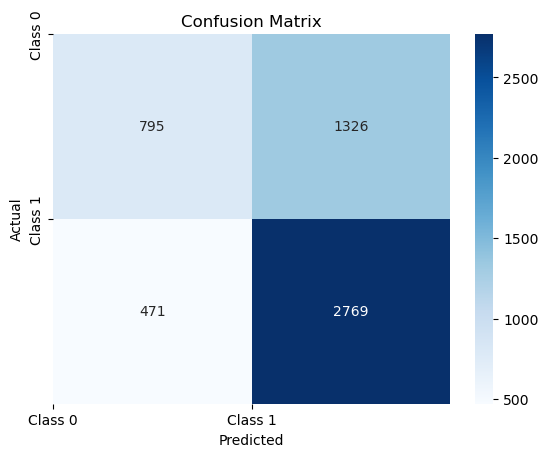

In [30]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.metrics import confusion_matrix
# Create confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Create a list of class labels
class_labels = ['Class 0', 'Class 1']

# Plot confusion matrix as heatmap
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_labels, yticklabels=class_labels)

# Add labels, title, and ticks
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.xticks(np.arange(len(class_labels)), class_labels)
plt.yticks(np.arange(len(class_labels)), class_labels)

# Show the plot
plt.show()

In [ ]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt
# Calculate the ROC curve and AUC
fpr, tpr, thresholds = roc_curve(y_test, y_pred)
auc = roc_auc_score(y_test, y_pred)

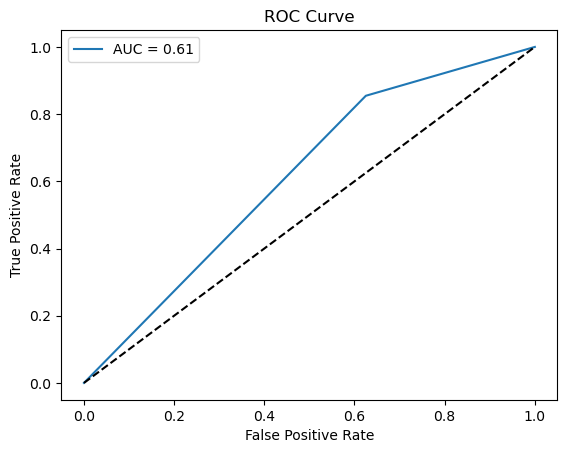

In [32]:
# Plot the ROC curve
plt.plot(fpr, tpr, label=f'AUC = {auc:.2f}')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()

### Ten runs of NB-classifier

In [208]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt
import pandas as pd

# List to store results
results = []

# Loop for 10 iterations
for i in range(10):
    print(f"\nIteration {i+1}")

    # Generate a random seed
    seed = random.randint(0, 101)

    # load the processed dataset
    # df = pd.read_csv("dataset-processed.csv")

    labels = ["True" if bioactivity >= 6 else "False" for bioactivity in bioactivity_data['pIC50']]

    # Perform stratified sampling
    #strat_df = df.groupby('labels', group_keys=False).apply(lambda x: x.sample(frac=0.6), random_state=seed)

    # Now split strat_df into X and y
    X = df.drop(['pIC50'], axis=1)
    y = labels

    # Encoding the Species column to get numerical class
    le = LabelEncoder()
    y = le.fit_transform(y)

    # Split the data into training and testing sets
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=seed, stratify=y)
    
    # Gaussian Naive Bayes classifier
    gnb = GaussianNB()

    # Train the classifier on the training data
    gnb.fit(X_train, y_train)
    
    # import performance metric libraries 
    from sklearn.metrics import (
    accuracy_score, 
    confusion_matrix, 
    ConfusionMatrixDisplay, 
    f1_score, 
    classification_report
    )
    # Make predictions on the testing data
    y_pred = gnb.predict(X_test)

    y_pred_train = gnb.predict(X_train)

    # measure the performance
    accuracy = accuracy_score(y_pred, y_test)
    accuracy_train = accuracy_score(y_pred_train, y_train)
    f1 = f1_score(y_pred, y_test, average="weighted") 

    print(f"The accuracy of my Naive Bayes Model is:, {accuracy:.3f}") 
    print(f"The accuracy of my Naive Bayes Model on training data is:, {accuracy_train:.3f}")
    print(f"The F1 Score of my Naive Bayes Model is:, {f1:.3f}")

    # Append results to the list
    results.append({"Iteration": i + 1, "Accuracy": accuracy, "Accuracy_Train": accuracy_train, "F1-Score": f1})

    # Calculate the ROC curve and AUC
    fpr, tpr, thresholds = roc_curve(y_test, y_pred)
    auc = roc_auc_score(y_test, y_pred)
    auc_train = roc_auc_score(y_train, y_pred_train)

    print(f"The area under the curve (AUC) is: , {auc:.3f}")

# Convert results to a DataFrame
results_df = pd.DataFrame(results)

# Print the table
#print("\nResults Table:")
#print(results_df)

# Save the table to a CSV file
# results_df.to_csv("results_table1.csv", index=False)


Iteration 1
The accuracy of my Naive Bayes Model is:, 0.657
The accuracy of my Naive Bayes Model on training data is:, 0.672
The F1 Score of my Naive Bayes Model is:, 0.680
The area under the curve (AUC) is: , 0.604

Iteration 2
The accuracy of my Naive Bayes Model is:, 0.667
The accuracy of my Naive Bayes Model on training data is:, 0.669
The F1 Score of my Naive Bayes Model is:, 0.685
The area under the curve (AUC) is: , 0.619

Iteration 3
The accuracy of my Naive Bayes Model is:, 0.680
The accuracy of my Naive Bayes Model on training data is:, 0.666
The F1 Score of my Naive Bayes Model is:, 0.704
The area under the curve (AUC) is: , 0.627

Iteration 4
The accuracy of my Naive Bayes Model is:, 0.669
The accuracy of my Naive Bayes Model on training data is:, 0.667
The F1 Score of my Naive Bayes Model is:, 0.688
The area under the curve (AUC) is: , 0.621

Iteration 5
The accuracy of my Naive Bayes Model is:, 0.669
The accuracy of my Naive Bayes Model on training data is:, 0.669
The F1

In [236]:
from sklearn.model_selection import StratifiedKFold
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score
from sklearn.model_selection import train_test_split
import numpy as np

# Prepare features and labels
labels = ["True" if bioactivity >= 6 else "False" for bioactivity in bioactivity_data['pIC50']]
y = labels
le = LabelEncoder()
y = le.fit_transform(y)
X = df.drop(['pIC50', "NumAtoms", "TPSA", "HBD", "Volume"], axis=1)


# Set up 5-fold stratified cross-validation
skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=101)

mean_accuracies = []
mean_accuracies_train = []
mean_f1s = []
mean_aucs = []
mean_aucs_train = []

for run in range(10):

    print(f"\nRun {run + 1}")
    
    run_accuracies = []
    run_accuracies_train = []
    run_f1s = []
    run_aucs = []
    run_aucs_train = []

    for fold, (train_idx, test_idx) in enumerate(skf.split(X, y), 1):
    
        # Generate a random seed
        seed = random.randint(0, 101) 

        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_test = y[train_idx], y[test_idx]
    
        # Split the data into training and testing sets (e.g., 80% train, 20% test)
        X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=seed, stratify=y)

        gnb = GaussianNB()
        gnb.fit(X_train, y_train)
        y_pred = gnb.predict(X_test)
        y_pred_train = gnb.predict(X_train)
    
        acc = accuracy_score(y_test, y_pred)
        acc_train = accuracy_score(y_train, y_pred_train)
        f1 = f1_score(y_test, y_pred, average='weighted')
        auc = roc_auc_score(y_test, y_pred)
        auc_train = roc_auc_score(y_train, y_pred_train)

        print(f"Fold {fold}: Accuracy={acc:.3f}, Accuracy_Train={acc_train:.3f}, F1={f1:.3f}, AUC={auc:.3f}, AUC_Train={auc_train:.3f}")
        run_accuracies.append(acc)
        run_accuracies_train.append(acc_train)
        run_f1s.append(f1)
        run_aucs.append(auc)
        run_aucs_train.append(auc_train)

    mean_accuracies.append(np.mean(run_accuracies))
    mean_accuracies_train.append(np.mean(run_accuracies_train))
    mean_f1s.append(np.mean(run_f1s))
    mean_aucs.append(np.mean(run_aucs))
    mean_aucs_train.append(np.mean(run_aucs_train))

    print(f"\nMean Accuracy: {np.mean(run_accuracies):.3f}")
    print(f"Mean Accuracy_Train: {np.mean(run_accuracies_train):.3f}")
    print(f"Mean F1: {np.mean(run_f1s):.3f}")
    print(f"Mean AUC: {np.mean(run_aucs):.3f}")
    print(f"Mean AUC_Train: {np.mean(run_aucs_train):.3f}")

# Convert results to a DataFrame using the mean lists
results_gnb_df = pd.DataFrame({
    "Run": np.arange(1, len(mean_accuracies) + 1),
    "Mean Accuracy": mean_accuracies,
    "Mean Train Accuracy": mean_accuracies_train,
    "Mean F1": mean_f1s,
    "Mean AUC": mean_aucs,
    "Mean Train AUC": mean_aucs_train
})

print ("\nResults DataFrame:")
print(results_gnb_df)


Run 1
Fold 1: Accuracy=0.665, Accuracy_Train=0.663, F1=0.650, AUC=0.621, AUC_Train=0.617
Fold 2: Accuracy=0.655, Accuracy_Train=0.666, F1=0.638, AUC=0.609, AUC_Train=0.620
Fold 3: Accuracy=0.661, Accuracy_Train=0.665, F1=0.645, AUC=0.616, AUC_Train=0.620
Fold 4: Accuracy=0.655, Accuracy_Train=0.667, F1=0.637, AUC=0.607, AUC_Train=0.621
Fold 5: Accuracy=0.659, Accuracy_Train=0.667, F1=0.644, AUC=0.616, AUC_Train=0.625
Fold 6: Accuracy=0.661, Accuracy_Train=0.666, F1=0.647, AUC=0.619, AUC_Train=0.622
Fold 7: Accuracy=0.658, Accuracy_Train=0.665, F1=0.642, AUC=0.613, AUC_Train=0.620
Fold 8: Accuracy=0.655, Accuracy_Train=0.667, F1=0.637, AUC=0.607, AUC_Train=0.621
Fold 9: Accuracy=0.662, Accuracy_Train=0.665, F1=0.645, AUC=0.615, AUC_Train=0.618
Fold 10: Accuracy=0.667, Accuracy_Train=0.663, F1=0.652, AUC=0.623, AUC_Train=0.618

Mean Accuracy: 0.660
Mean Accuracy_Train: 0.665
Mean F1: 0.644
Mean AUC: 0.615
Mean AUC_Train: 0.620

Run 2
Fold 1: Accuracy=0.666, Accuracy_Train=0.663, F1=0.65

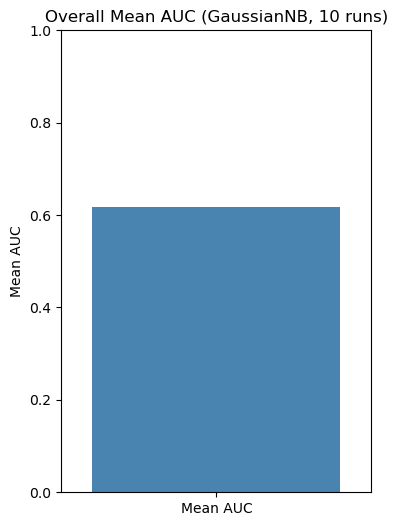

In [249]:
# ...existing code...
import seaborn as sns
import matplotlib.pyplot as plt

overall_mean_auc = results_gnb_df["Mean AUC"].mean()

plt.figure(figsize=(4, 6))
sns.barplot(x=["Mean AUC"], y=[overall_mean_auc], palette="Blues_d")
plt.ylabel("Mean AUC")
plt.title("Overall Mean AUC (GaussianNB, 10 runs)")
plt.ylim(0, 1)
plt.show()
# ...existing code...

# ML Proyect for MoML in Montreal 
### Logistic Regression applied to a set of compound with biological activity against tyrosine kinases.

In [97]:
import numpy

In [98]:
# Loads the bioactivity data into a Pandas dataframe
bioactivity_data = pd.read_csv("ligands_descriptors_updated.csv", sep=';')
print(bioactivity_data.iloc[:,0:11])

                                                  SMILES   MolWt  LogP  HBD  \
0      CCCCc1ccc(Nc2nnc3cc(-c4cc(OC)cc(OC)c4)cc(C)c3n...  428.54  6.10    1   
1      CONC(=O)CCc1c(SSc2[nH]c3ccccc3c2CCC(=O)NOC)[nH...  498.63  4.67    4   
2                  COc1cc(O)c2c(c1)-c1cc(O)c(O)cc1COC2=O  288.26  2.15    3   
3            COc1cccc(-c2nc3c(O)nc(NC(C)=O)nc3[nH]2)c1OC  329.32  1.70    3   
4      Cc1nc2cc(-n3ncc(C(=O)c4cc5cc(C(C)(C)C)ccc5[nH]...  412.50  4.65    3   
...                                                  ...     ...   ...  ...   
21436  C#Cc1cccc(Nc2ncnc3cc(OCCCCCCn4ccnc4[N+](=O)[O-...  486.53  5.11    1   
21437                          OCCNc1ncnc2sc3c(c12)CCCC3  249.34  1.97    2   
21438        O=C1Nc2ccccc2/C1=C1/Nc2ccccc2/C1=N\OCC(O)CO  351.36  1.55    4   
21439  COc1cc2c(Oc3ccc(-c4nc5ccccc5s4)cc3F)ncnc2cc1OC...  559.67  5.86    0   
21440     COc1cc2c(Nc3ccc(Cl)cc3F)ncnc2cc1OCCC1CCN(C)CC1  444.94  5.29    1   

       HBA  RotatableBonds    TPSA  Volume  Lipinsk

In [99]:
#bioactivity_data.drop('molecule_chembl_id', axis=1, inplace=True)
#bioactivity_data.drop('canonical_smiles', axis=1, inplace=True)
#bioactivity_data.drop('standard_value', axis=1, inplace=True)
bioactivity_data.drop('SMILES', axis=1, inplace=True)

bioactivity_data.to_csv("dataset-processed.csv", index=False)
# Let's see what's in the Bank-full data - Jupyter notebooks print the result of the last thing you do
df = pd.read_csv("dataset-processed.csv")  

df.head()

,MolWt,LogP,HBD,HBA,RotatableBonds,TPSA,Volume,LipinskiViolations,NumAtoms,pIC50
0,428.54,6.10,1,6,8,69.16,257.96,1,32,4.000000
1,498.63,4.67,4,6,11,108.24,300.08,0,34,5.537602
2,288.26,2.15,3,6,1,96.22,173.53,0,21,8.000000
3,329.32,1.70,3,7,4,122.25,198.26,0,24,5.039529
4,412.50,4.65,3,5,3,105.38,248.31,0,31,6.823909


In [100]:
from sklearn import linear_model

In [101]:
# Converts the bioactivity data to binary classification labels
labels = [1 if bioactivity >= 6 else 0 for bioactivity in bioactivity_data['pIC50']]

In [103]:
# We will split the dataset into training and testing sets 
X = df.drop(["pIC50", "NumAtoms", "TPSA", "HBD", "Volume"], axis=1)
y = labels

df.head()

,MolWt,LogP,HBD,HBA,RotatableBonds,TPSA,Volume,LipinskiViolations,NumAtoms,pIC50
0,428.54,6.10,1,6,8,69.16,257.96,1,32,4.000000
1,498.63,4.67,4,6,11,108.24,300.08,0,34,5.537602
2,288.26,2.15,3,6,1,96.22,173.53,0,21,8.000000
3,329.32,1.70,3,7,4,122.25,198.26,0,24,5.039529
4,412.50,4.65,3,5,3,105.38,248.31,0,31,6.823909


In [211]:
# Encoding the outcome column to get numerical class
le = LabelEncoder()
y = le.fit_transform(y)

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=101)


In [212]:
logr = linear_model.LogisticRegression(max_iter=5000) 
logr.fit(X_train, y_train)

LogisticRegression(max_iter=5000)

In [213]:
# import performance metric libraries 
from sklearn.metrics import (
accuracy_score, 
confusion_matrix, 
ConfusionMatrixDisplay, 
f1_score, 
classification_report
)

In [214]:
# Make predictions on the testing data
y_pred = logr.predict(X_test)
y_pred_train = logr.predict(X_train)

# measure the performance
accuracy = accuracy_score(y_pred, y_test)
accuracy_train = accuracy_score(y_pred_train, y_train)
f1 = f1_score(y_pred, y_test, average="weighted") 
print("The accuracy of my Logistic Regression Model is:", accuracy) 
print("The accuracy of my Logistic Regression Model on training data is:", accuracy_train)
print("The F1 Score of my Logistic Regression Model is:", f1)

The accuracy of my Logistic Regression Model is: 0.6640552135795561
The accuracy of my Logistic Regression Model on training data is: 0.6716417910447762
The F1 Score of my Logistic Regression Model is: 0.691005449007312


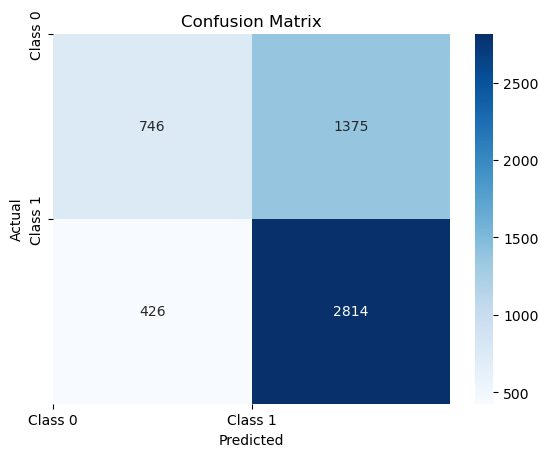

In [108]:
import seaborn as sns
from sklearn.metrics import confusion_matrix
# Create confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Create a list of class labels
class_labels = ['Class 0', 'Class 1']

# Plot confusion matrix as heatmap
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_labels, yticklabels=class_labels)

# Add labels, title, and ticks
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.xticks(np.arange(len(class_labels)), class_labels)
plt.yticks(np.arange(len(class_labels)), class_labels)

# Show the plot
plt.show()

In [109]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt
# Calculate the ROC curve and AUC
fpr, tpr, thresholds = roc_curve(y_test, y_pred)
auc = roc_auc_score(y_test, y_pred)

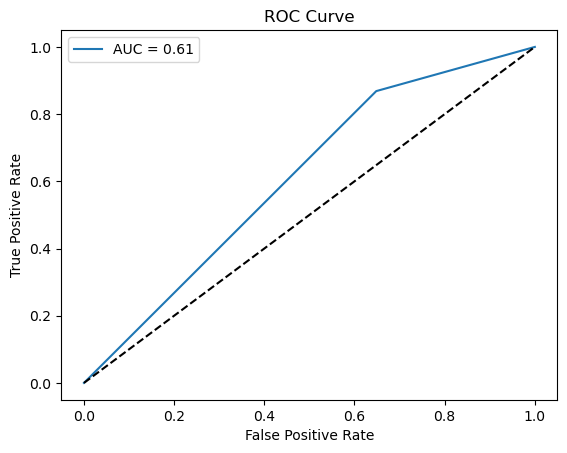

In [110]:
# Plot the ROC curve
plt.plot(fpr, tpr, label=f'AUC = {auc:.2f}')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()

### Ten iterations run

In [215]:
from sklearn import linear_model

# List to store results
results = []

# Loop for 10 iterations
for i in range(10):
    print(f"\nIteration {i+1}")

    # Generate a random seed
    seed = random.randint(0, 10000)

    # Converts the bioactivity data to binary classification labels
    labels = [1 if bioactivity >= 6 else 0 for bioactivity in bioactivity_data['pIC50']]
    # We will split the dataset into training and testing sets 
    X = df.drop(["pIC50", "NumAtoms", "TPSA", "HBD", "Volume"], axis=1)
    y = labels


    # Encoding the outcome column to get numerical class
    le = LabelEncoder()
    y = le.fit_transform(y)

    # Split the data into training and testing sets
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=seed, stratify=y)

    logr = linear_model.LogisticRegression(max_iter=5000) 
    logr.fit(X_train, y_train)
    # import performance metric libraries 
    from sklearn.metrics import (
    accuracy_score, 
    confusion_matrix, 
    ConfusionMatrixDisplay, 
    f1_score, 
    classification_report
    )
    # Make predictions on the testing data
    y_pred = logr.predict(X_test)
    y_pred_train = logr.predict(X_train)

    # measure the performance
    accuracy = accuracy_score(y_pred, y_test)
    accuracy_train = accuracy_score(y_pred_train, y_train)
    f1 = f1_score(y_pred, y_test, average="weighted") 
    print(f"The accuracy of my Logistic Regression Model is: {accuracy:.3f}") 
    print(f"The accuracy of my Logistic Regression Model on training data is: {accuracy_train:.3f}")
    print(f"The F1 Score of my Logistic Regression Model is: {f1:.3f}")

    # Append results to the list
    results.append({"Iteration": i + 1, "Accuracy": accuracy, "Accuracy_Train": accuracy_train, "F1-Score": f1})

    # Calculate the ROC curve and AUC
    fpr, tpr, thresholds = roc_curve(y_test, y_pred)
    auc = roc_auc_score(y_test, y_pred)

    print(f"The area under the curve (AUC) is: {auc:.3f}")    

# Convert results to a DataFrame
results_df = pd.DataFrame(results)


Iteration 1
The accuracy of my Logistic Regression Model is: 0.665
The accuracy of my Logistic Regression Model on training data is: 0.670
The F1 Score of my Logistic Regression Model is: 0.692
The area under the curve (AUC) is: 0.609

Iteration 2
The accuracy of my Logistic Regression Model is: 0.675
The accuracy of my Logistic Regression Model on training data is: 0.668
The F1 Score of my Logistic Regression Model is: 0.703
The area under the curve (AUC) is: 0.616

Iteration 3
The accuracy of my Logistic Regression Model is: 0.675
The accuracy of my Logistic Regression Model on training data is: 0.668
The F1 Score of my Logistic Regression Model is: 0.701
The area under the curve (AUC) is: 0.619

Iteration 4
The accuracy of my Logistic Regression Model is: 0.668
The accuracy of my Logistic Regression Model on training data is: 0.670
The F1 Score of my Logistic Regression Model is: 0.695
The area under the curve (AUC) is: 0.612

Iteration 5
The accuracy of my Logistic Regression Mode

In [235]:
from sklearn.model_selection import StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import random
import numpy as np
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score

# Converts the bioactivity data to binary classification labels
labels = [1 if bioactivity >= 6 else 0 for bioactivity in bioactivity_data['pIC50']]

# We will split the dataset into training and testing sets 
X = df.drop(["pIC50", "NumAtoms", "Volume", "HBD"], axis=1)
y = labels

# Encoding the outcome column to get numerical class
le = LabelEncoder()
y = le.fit_transform(y)

skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=0)

mean_accuracies = []
mean_accuracies_train = []
mean_f1s = []
mean_aucs = []
mean_aucs_train = []

for i in range(10):
    print(f"\nIteration {i+1}")

    run_accuracies = []
    run_accuracies_train = []
    run_f1s = []
    run_aucs = []
    run_aucs_train = []

    for fold, (train_idx, test_idx) in enumerate(skf.split(X, y), 1):

        seed = random.randint(0, 101)  # Generate a random seed
    
        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_test = y[train_idx], y[test_idx]
    
        # Split the data into training and testing sets (e.g., 80% train, 20% test)
        X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=seed, stratify=y)

        logr = LogisticRegression(max_iter=100000)
        logr.fit(X_train, y_train)
        y_pred = logr.predict(X_test)
        y_pred_train = logr.predict(X_train)
        
        acc = accuracy_score(y_test, y_pred)
        acc_train = accuracy_score(y_train, y_pred_train)
        f1 = f1_score(y_test, y_pred, average="weighted")
        auc = roc_auc_score(y_test, y_pred)
        auc_train_value = roc_auc_score(y_train, y_pred_train)
    

        print(f"Fold {fold}: Accuracy={acc:.3f}, AccTrain={acc_train:.3f}, F1={f1:.3f}, AUC={auc:.3f}, AUC_Train={auc_train_value:.3f}")
        run_accuracies.append(acc)
        run_accuracies_train.append(acc_train)
        run_f1s.append(f1)
        run_aucs.append(auc)
        run_aucs_train.append(auc_train_value)

    mean_accuracies.append(np.mean(run_accuracies))
    mean_accuracies_train.append(np.mean(run_accuracies_train))
    mean_f1s.append(np.mean(run_f1s))
    mean_aucs.append(np.mean(run_aucs))
    mean_aucs_train.append(np.mean(run_aucs_train))

    print(f"Mean Accuracy: {np.mean(run_accuracies):.3f}")
    print(f"Mean Train Accuracy: {np.mean(run_accuracies_train):.3f}")
    print(f"Mean F1: {np.mean(run_f1s):.3f}")
    print(f"Mean AUC: {np.mean(run_aucs):.3f}")
    print(f"Mean Train AUC: {np.mean(run_aucs_train):.3f}")
    
    
# Convert results to a DataFrame using the mean lists
results_lg_df = pd.DataFrame({
    "Run": np.arange(1, len(mean_accuracies) + 1),
    "Mean Accuracy": mean_accuracies,
    "Mean Train Accuracy": mean_accuracies_train,
    "Mean F1": mean_f1s,
    "Mean AUC": mean_aucs,
    "Mean Train AUC": mean_aucs_train
})

print ("\nResults DataFrame:")
print(results_lg_df)


Iteration 1
Fold 1: Accuracy=0.668, AccTrain=0.670, F1=0.648, AUC=0.619, AUC_Train=0.622
Fold 2: Accuracy=0.671, AccTrain=0.669, F1=0.651, AUC=0.621, AUC_Train=0.622
Fold 3: Accuracy=0.674, AccTrain=0.669, F1=0.656, AUC=0.627, AUC_Train=0.621
Fold 4: Accuracy=0.673, AccTrain=0.670, F1=0.654, AUC=0.625, AUC_Train=0.622
Fold 5: Accuracy=0.673, AccTrain=0.669, F1=0.656, AUC=0.627, AUC_Train=0.620
Fold 6: Accuracy=0.665, AccTrain=0.672, F1=0.644, AUC=0.614, AUC_Train=0.625
Fold 7: Accuracy=0.663, AccTrain=0.670, F1=0.645, AUC=0.615, AUC_Train=0.623
Fold 8: Accuracy=0.667, AccTrain=0.668, F1=0.650, AUC=0.620, AUC_Train=0.621
Fold 9: Accuracy=0.666, AccTrain=0.672, F1=0.647, AUC=0.618, AUC_Train=0.624
Fold 10: Accuracy=0.679, AccTrain=0.667, F1=0.662, AUC=0.632, AUC_Train=0.619
Mean Accuracy: 0.670
Mean Train Accuracy: 0.670
Mean F1: 0.651
Mean AUC: 0.622
Mean Train AUC: 0.622

Iteration 2
Fold 1: Accuracy=0.657, AccTrain=0.671, F1=0.639, AUC=0.610, AUC_Train=0.624
Fold 2: Accuracy=0.674, A

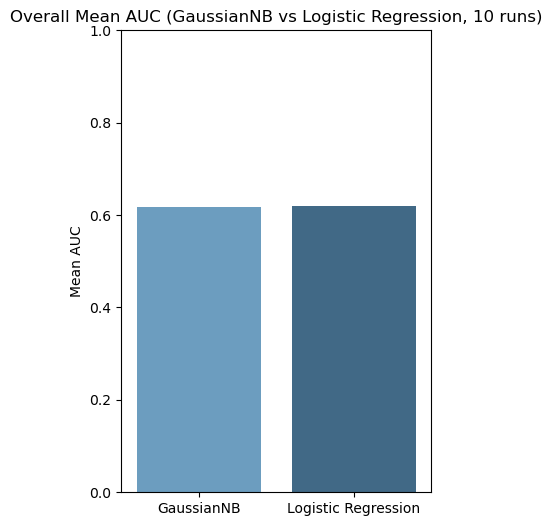

In [252]:
# ...existing code...
import seaborn as sns
import matplotlib.pyplot as plt

gnb_overall_mean_auc = results_gnb_df["Mean AUC"].mean()
lg_overall_mean_auc = results_lg_df["Mean AUC"].mean()

plt.figure(figsize=(4, 6))
sns.barplot(x=["GaussianNB", "Logistic Regression"], y=[gnb_overall_mean_auc, lg_overall_mean_auc], palette="Blues_d")
plt.ylabel("Mean AUC")
plt.title("Overall Mean AUC (GaussianNB vs Logistic Regression, 10 runs)")
plt.ylim(0, 1)
plt.show()


# ML Proyect for MoML in Montreal 
### Decision Tree Classifier applied to a set of compound with biological activity against tyrosine kinases.

In [68]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt # data visualization
import seaborn as sns # statistical data visualization
%matplotlib inline
import warnings

warnings.filterwarnings('ignore')

In [69]:
# Loads the bioactivity data into a Pandas dataframe
bioactivity_data = pd.read_csv("ligands_descriptors_updated.csv", sep=';')
print(bioactivity_data.iloc[:,0:11])

                                                  SMILES   MolWt  LogP  HBD  \
0      CCCCc1ccc(Nc2nnc3cc(-c4cc(OC)cc(OC)c4)cc(C)c3n...  428.54  6.10    1   
1      CONC(=O)CCc1c(SSc2[nH]c3ccccc3c2CCC(=O)NOC)[nH...  498.63  4.67    4   
2                  COc1cc(O)c2c(c1)-c1cc(O)c(O)cc1COC2=O  288.26  2.15    3   
3            COc1cccc(-c2nc3c(O)nc(NC(C)=O)nc3[nH]2)c1OC  329.32  1.70    3   
4      Cc1nc2cc(-n3ncc(C(=O)c4cc5cc(C(C)(C)C)ccc5[nH]...  412.50  4.65    3   
...                                                  ...     ...   ...  ...   
21436  C#Cc1cccc(Nc2ncnc3cc(OCCCCCCn4ccnc4[N+](=O)[O-...  486.53  5.11    1   
21437                          OCCNc1ncnc2sc3c(c12)CCCC3  249.34  1.97    2   
21438        O=C1Nc2ccccc2/C1=C1/Nc2ccccc2/C1=N\OCC(O)CO  351.36  1.55    4   
21439  COc1cc2c(Oc3ccc(-c4nc5ccccc5s4)cc3F)ncnc2cc1OC...  559.67  5.86    0   
21440     COc1cc2c(Nc3ccc(Cl)cc3F)ncnc2cc1OCCC1CCN(C)CC1  444.94  5.29    1   

       HBA  RotatableBonds    TPSA  Volume  Lipinsk

In [70]:
# view dimensions of dataset

bioactivity_data.shape

(21441, 11)

In [71]:
#bioactivity_data.drop('molecule_chembl_id', axis=1, inplace=True)
#bioactivity_data.drop('canonical_smiles', axis=1, inplace=True)
#bioactivity_data.drop('standard_value', axis=1, inplace=True)
bioactivity_data.drop('SMILES', axis=1, inplace=True)

bioactivity_data.to_csv("dataset-processed.csv", index=False)
# Let's see what's in the Bank-full data - Jupyter notebooks print the result of the last thing you do
df = pd.read_csv("dataset-processed.csv")  

df.head()

,MolWt,LogP,HBD,HBA,RotatableBonds,TPSA,Volume,LipinskiViolations,NumAtoms,pIC50
0,428.54,6.10,1,6,8,69.16,257.96,1,32,4.000000
1,498.63,4.67,4,6,11,108.24,300.08,0,34,5.537602
2,288.26,2.15,3,6,1,96.22,173.53,0,21,8.000000
3,329.32,1.70,3,7,4,122.25,198.26,0,24,5.039529
4,412.50,4.65,3,5,3,105.38,248.31,0,31,6.823909


In [72]:
bioactivity_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21441 entries, 0 to 21440
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   MolWt               21441 non-null  float64
 1   LogP                21441 non-null  float64
 2   HBD                 21441 non-null  int64  
 3   HBA                 21441 non-null  int64  
 4   RotatableBonds      21441 non-null  int64  
 5   TPSA                21441 non-null  float64
 6   Volume              21441 non-null  float64
 7   LipinskiViolations  21441 non-null  int64  
 8   NumAtoms            21441 non-null  int64  
 9   pIC50               21441 non-null  float64
dtypes: float64(5), int64(5)
memory usage: 1.6 MB


In [73]:
# check missing values in variables

bioactivity_data.isnull().sum()

MolWt                 0
LogP                  0
HBD                   0
HBA                   0
RotatableBonds        0
TPSA                  0
Volume                0
LipinskiViolations    0
NumAtoms              0
pIC50                 0
dtype: int64

In [74]:
# Converts the bioactivity data to binary classification labels
labels = [1 if bioactivity >= 6 else 0 for bioactivity in bioactivity_data['pIC50']]

In [75]:
# We will split the dataset into training and testing sets 
X = df.drop("pIC50", axis=1)
y = labels

df.head()

,MolWt,LogP,HBD,HBA,RotatableBonds,TPSA,Volume,LipinskiViolations,NumAtoms,pIC50
0,428.54,6.10,1,6,8,69.16,257.96,1,32,4.000000
1,498.63,4.67,4,6,11,108.24,300.08,0,34,5.537602
2,288.26,2.15,3,6,1,96.22,173.53,0,21,8.000000
3,329.32,1.70,3,7,4,122.25,198.26,0,24,5.039529
4,412.50,4.65,3,5,3,105.38,248.31,0,31,6.823909


In [76]:
# split X and y into training and testing sets

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.25, random_state = 101)

In [77]:
# check the shape of X_train and X_test

X_train.shape, X_test.shape

((16080, 9), (5361, 9))

In [78]:
# check data types in X_train

X_train.dtypes

MolWt                 float64
LogP                  float64
HBD                     int64
HBA                     int64
RotatableBonds          int64
TPSA                  float64
Volume                float64
LipinskiViolations      int64
NumAtoms                int64
dtype: object

In [79]:
# import DecisionTreeClassifier

from sklearn.tree import DecisionTreeClassifier

In [80]:
# instantiate the DecisionTreeClassifier model with criterion gini index

clf_gini = DecisionTreeClassifier(criterion='gini', max_depth=None, random_state=0)

# fit the model
clf_gini.fit(X_train, y_train)

DecisionTreeClassifier(random_state=0)

In [81]:
y_pred_gini = clf_gini.predict(X_test)


In [82]:
from sklearn.metrics import accuracy_score

print('Model accuracy score with criterion gini index: {0:0.4f}'. format(accuracy_score(y_test, y_pred_gini)))

Model accuracy score with criterion gini index: 0.7260


In [83]:
y_pred_train_gini = clf_gini.predict(X_train)

y_pred_train_gini

array([1, 1, 1, ..., 1, 0, 1])

In [84]:
print('Training-set accuracy score: {0:0.4f}'. format(accuracy_score(y_train, y_pred_train_gini)))

Training-set accuracy score: 0.9548


In [166]:
plt.figure(figsize=(12,8))

from sklearn import tree

tree.plot_tree(clf_gini.fit(X_train, y_train)) 

[Text(0.4648609396374248, 0.9761904761904762, 'x[8] <= 29.5\ngini = 0.475\nsamples = 16080\nvalue = [6258, 9822]'),
 Text(0.10930843254664777, 0.9285714285714286, 'x[3] <= 3.5\ngini = 0.495\nsamples = 6035\nvalue = [3320.0, 2715.0]'),
 Text(0.027906746750736823, 0.8809523809523809, 'x[5] <= 50.835\ngini = 0.371\nsamples = 1073\nvalue = [809, 264]'),
 Text(0.004861815722085327, 0.8333333333333334, 'x[1] <= 1.9\ngini = 0.256\nsamples = 525\nvalue = [446, 79]'),
 Text(0.0009663236217809344, 0.7857142857142857, 'x[5] <= 4.745\ngini = 0.198\nsamples = 9\nvalue = [1, 8]'),
 Text(0.0005797941730685607, 0.7380952380952381, 'gini = 0.0\nsamples = 1\nvalue = [1, 0]'),
 Text(0.0013528530704933082, 0.7380952380952381, 'gini = 0.0\nsamples = 8\nvalue = [0, 8]'),
 Text(0.008757307822389718, 0.7857142857142857, 'x[0] <= 271.43\ngini = 0.237\nsamples = 516\nvalue = [445, 71]'),
 Text(0.002125911967918056, 0.7380952380952381, 'x[1] <= 3.36\ngini = 0.085\nsamples = 180\nvalue = [172, 8]'),
 Text(0.00077

Error in callback <function flush_figures at 0x146d43ce0> (for post_execute), with arguments args (),kwargs {}:


KeyboardInterrupt: 

In [85]:
# Print the Confusion Matrix and slice it into four pieces

from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred_gini)

print('Confusion matrix\n\n', cm)

Confusion matrix

 [[1485  636]
 [ 833 2407]]


In [200]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_gini))

              precision    recall  f1-score   support

           0       0.65      0.70      0.67      2095
           1       0.80      0.76      0.78      3266

    accuracy                           0.74      5361
   macro avg       0.72      0.73      0.73      5361
weighted avg       0.74      0.74      0.74      5361



In [201]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt
# Calculate the ROC curve and AUC
fpr, tpr, thresholds = roc_curve(y_test, y_pred_gini)
auc = roc_auc_score(y_test, y_pred_gini)

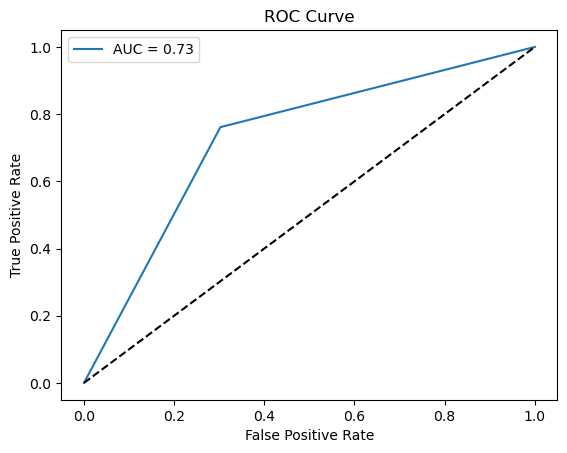

In [202]:
# Plot the ROC curve
plt.plot(fpr, tpr, label=f'AUC = {auc:.2f}')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()

In [88]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt # data visualization
import seaborn as sns # statistical data visualization
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
%matplotlib inline
import warnings

warnings.filterwarnings('ignore')

# List to store results
results = []

# Loop for 10 iterations
for i in range(10):
    print(f"\nIteration {i+1}")

    # Generate a random seed
    seed = random.randint(0, 10000)

    # Converts the bioactivity data to binary classification labels
    labels = [1 if bioactivity >= 6 else 0 for bioactivity in bioactivity_data['pIC50']]
    # We will split the dataset into training and testing sets 
    X = df.drop("pIC50", axis=1)
    y = labels


    # Encoding the outcome column to get numerical class
    le = LabelEncoder()
    y = le.fit_transform(y)

    # Split the data into training and testing sets
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=seed, stratify=y)

    clf_gini = DecisionTreeClassifier(criterion='gini', max_depth=None, random_state=101)


    # fit the model
    clf_gini.fit(X_train, y_train)
    
    y_pred_gini = clf_gini.predict(X_test)

    y_pred_train_gini = clf_gini.predict(X_train)

    # import performance metric libraries 
    from sklearn.metrics import (
    accuracy_score, 
    confusion_matrix, 
    ConfusionMatrixDisplay, 
    f1_score, 
    classification_report
    )
    # Make predictions on the testing data
    #y_pred_train_gini = clf_gini.predict(X_train)

    #y_pred_train_gini   

    # measure the performance
    accuracy = accuracy_score(y_pred_gini, y_test)
    accuracy_train = accuracy_score(y_pred_train_gini, y_train)
    f1 = f1_score(y_pred_gini, y_test, average="weighted") 
    print(f"The accuracy of my Logistic Regression Model is: {accuracy:.3f}") 
    print(f"The accuracy of my Logistic Regression Model on training set is: {accuracy_train:.3f}")
    print(f"The F1 Score of my Logistic Regression Model is: {f1:.3f}")

    # Append results to the list
    results.append({"Iteration": i + 1, "Accuracy": accuracy, "F1-Score": f1})

    # Calculate the ROC curve and AUC
    fpr, tpr, thresholds = roc_curve(y_test, y_pred_gini)
    auc = roc_auc_score(y_test, y_pred_gini)
    auc_train = roc_auc_score(y_train, y_pred_train_gini)

    print(f"The area under the curve (AUC) is: {auc:.3f}")
    print(f"The area under the curve (AUC) on training set is: {auc_train:.3f}")

# Convert results to a DataFrame
results_df = pd.DataFrame(results)


Iteration 1
The accuracy of my Logistic Regression Model is: 0.724
The accuracy of my Logistic Regression Model on training set is: 0.954
The F1 Score of my Logistic Regression Model is: 0.722
The area under the curve (AUC) is: 0.718
The area under the curve (AUC) on training set is: 0.957

Iteration 2
The accuracy of my Logistic Regression Model is: 0.725
The accuracy of my Logistic Regression Model on training set is: 0.952
The F1 Score of my Logistic Regression Model is: 0.723
The area under the curve (AUC) is: 0.721
The area under the curve (AUC) on training set is: 0.957

Iteration 3
The accuracy of my Logistic Regression Model is: 0.740
The accuracy of my Logistic Regression Model on training set is: 0.954
The F1 Score of my Logistic Regression Model is: 0.739
The area under the curve (AUC) is: 0.734
The area under the curve (AUC) on training set is: 0.957

Iteration 4
The accuracy of my Logistic Regression Model is: 0.734
The accuracy of my Logistic Regression Model on training

In [89]:
from sklearn.model_selection import StratifiedKFold
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
import random
import numpy as np
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score
import numpy as np

# Prepare features and labels
labels = [1 if bioactivity >= 6 else 0 for bioactivity in bioactivity_data['pIC50']]
le = LabelEncoder()
y = le.fit_transform(labels)
X = df.drop("pIC50", axis=1)

skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=101)

mean_accuracies = []
mean_accuracies_train = []
mean_f1s = []
mean_aucs = []
mean_aucs_train = []

for run in range(10):

    print(f"\nRun {run + 1}")

    run_accuracies = []
    run_accuracies_train = []
    run_f1s = []
    run_aucs = []
    run_aucs_train = []

    for fold, (train_idx, test_idx) in enumerate(skf.split(X, y), 1):

        seed = random.randint(0, 101)  # Generate a random seed
    
        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_test = y[train_idx], y[test_idx]

        # Split the data into training and testing sets (e.g., 80% train, 20% test)
        X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=seed, stratify=y)

        clf = DecisionTreeClassifier(max_depth=15, random_state=seed)
        clf.fit(X_train, y_train)
        y_pred = clf.predict(X_test)

        y_pred_train = clf.predict(X_train)

        acc = accuracy_score(y_test, y_pred)
        acc_train = accuracy_score(y_train, y_pred_train)
        f1 = f1_score(y_test, y_pred, average="weighted")
        auc = roc_auc_score(y_test, y_pred)
        auc_train = roc_auc_score(y_train, y_pred_train)

        print(f"Fold {fold}: Accuracy={acc:.3f}, AccTrain={acc_train:.3f}, F1={f1:.3f}, AUC={auc:.3f}, AUCTrain={auc_train:.3f}")
        run_accuracies.append(acc)
        run_accuracies_train.append(acc_train)
        run_f1s.append(f1)
        run_aucs.append(auc)
        run_aucs_train.append(auc_train)

    mean_accuracies.append(np.mean(run_accuracies))
    mean_accuracies_train.append(np.mean(run_accuracies_train))
    mean_f1s.append(np.mean(run_f1s))
    mean_aucs.append(np.mean(run_aucs))
    mean_aucs_train.append(np.mean(run_aucs_train))

    print(f"\nMean Accuracy: {np.mean(run_accuracies):.3f}")
    print(f"Mean Train Accuracy: {np.mean(run_accuracies_train):.3f}")
    print(f"Mean F1: {np.mean(run_f1s):.3f}")
    print(f"Mean AUC: {np.mean(run_aucs):.3f}")
    print(f"Mean Train AUC: {np.mean(run_aucs_train):.3f}")

# Convert results to a DataFrame
results_df_dt = pd.DataFrame({
    "Run": np.arange(1, 11),
    "Mean Accuracy": mean_accuracies,
    "Mean Train Accuracy": mean_accuracies_train,
    "Mean F1": mean_f1s,
    "Mean AUC": mean_aucs,
    "Mean Train AUC": mean_aucs_train
})

print ("\nResults DataFrame:")
print(results_df_dt)


Run 1
Fold 1: Accuracy=0.740, AccTrain=0.846, F1=0.735, AUC=0.713, AUCTrain=0.825
Fold 2: Accuracy=0.721, AccTrain=0.858, F1=0.720, AUC=0.703, AUCTrain=0.845
Fold 3: Accuracy=0.733, AccTrain=0.865, F1=0.729, AUC=0.707, AUCTrain=0.845
Fold 4: Accuracy=0.740, AccTrain=0.860, F1=0.735, AUC=0.712, AUCTrain=0.839
Fold 5: Accuracy=0.731, AccTrain=0.848, F1=0.727, AUC=0.705, AUCTrain=0.829
Fold 6: Accuracy=0.732, AccTrain=0.857, F1=0.726, AUC=0.703, AUCTrain=0.835
Fold 7: Accuracy=0.733, AccTrain=0.862, F1=0.731, AUC=0.713, AUCTrain=0.847
Fold 8: Accuracy=0.735, AccTrain=0.838, F1=0.728, AUC=0.703, AUCTrain=0.814
Fold 9: Accuracy=0.731, AccTrain=0.851, F1=0.724, AUC=0.700, AUCTrain=0.827
Fold 10: Accuracy=0.735, AccTrain=0.844, F1=0.730, AUC=0.706, AUCTrain=0.819

Mean Accuracy: 0.733
Mean Train Accuracy: 0.853
Mean F1: 0.728
Mean AUC: 0.707
Mean Train AUC: 0.833

Run 2
Fold 1: Accuracy=0.737, AccTrain=0.855, F1=0.732, AUC=0.710, AUCTrain=0.835
Fold 2: Accuracy=0.731, AccTrain=0.857, F1=0.72

In [90]:
# ...existing code...
import seaborn as sns
import matplotlib.pyplot as plt

gnb_overall_mean_auc = results_gnb_df["Mean AUC"].mean()
gnb_overall_std_auc = results_gnb_df["Mean AUC"].std()
lg_overall_mean_auc = results_lg_df["Mean AUC"].mean()
lg_overall_std_auc = results_lg_df["Mean AUC"].std()
dt_overall_mean_auc = results_df_dt["Mean AUC"].mean()
dt_overall_std_auc = results_df_dt["Mean AUC"].std()

plt.figure(figsize=(4, 6))
x_labels = ["GNB", "LogReg", "DecTree"]
mean_aucs = [gnb_overall_mean_auc, lg_overall_mean_auc, dt_overall_mean_auc]
std_aucs = [gnb_overall_std_auc, lg_overall_std_auc, dt_overall_std_auc]
plt.bar(x_labels, mean_aucs, yerr=std_aucs, color=sns.color_palette("Blues_d", 3), capsize=8)
plt.ylabel("Mean AUC")
plt.title("Overall Mean AUC (GNB vs Log Reg vs DecTree, 10 runs)")
plt.ylim(0, 1)
plt.show()


NameError: name 'results_gnb_df' is not defined

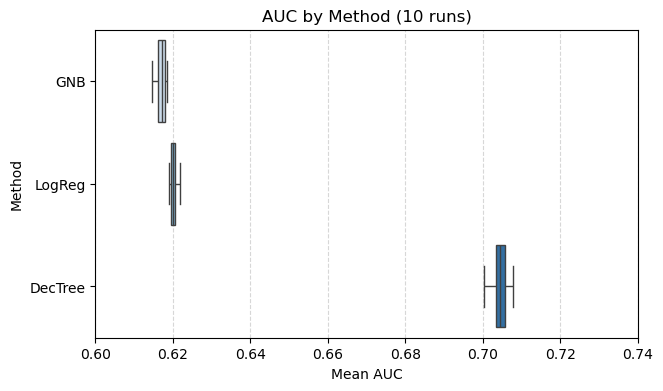

In [294]:
# ...existing code...
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Combine the "Mean AUC" values from each method into a single DataFrame
df_gnb = pd.DataFrame({
    "Method": "GNB",
    "Mean AUC": results_gnb_df["Mean AUC"]
})
df_lg = pd.DataFrame({
    "Method": "LogReg",
    "Mean AUC": results_lg_df["Mean AUC"]
})
df_dt = pd.DataFrame({
    "Method": "DecTree",
    "Mean AUC": results_df_dt["Mean AUC"]
})

# Concatenate all results
all_results = pd.concat([df_gnb, df_lg, df_dt], ignore_index=True)

plt.figure(figsize=(7, 4))
sns.boxplot(data=all_results, y="Method", x="Mean AUC", palette="Blues")
plt.title("AUC by Method (10 runs)")
plt.xlim(0.6, 0.74)
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.show()
# ...existing code...

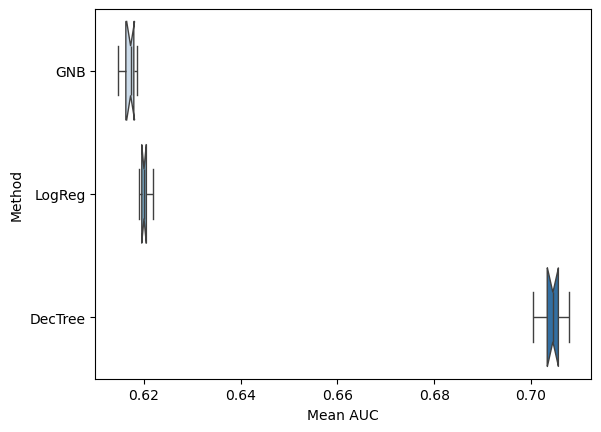

In [295]:
ax = sns.boxplot(data=all_results, y="Method", x="Mean AUC", palette="Blues", notch=True)

In [91]:
# Example: aucs_gnb, aucs_lg, aucs_dt are lists of lists (shape: 10 runs × 10 folds)
# Flatten and build a DataFrame for plotting

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

def build_auc_df(auc_list, method_name):
    df = pd.DataFrame(auc_list)
    df = df.melt(var_name="Fold", value_name="AUC")
    df["Run"] = df.index + 1
    df["Method"] = method_name
    return df

# Example placeholder: use the "Mean AUC" columns as 10 runs × 1 fold lists
aucs_gnb = [ [auc] for auc in results_gnb_df["Mean AUC"].tolist() ]
aucs_lg = [ [auc] for auc in results_lg_df["Mean AUC"].tolist() ]
aucs_dt = [ [auc] for auc in results_df["Mean AUC"].tolist()[:10] ]  # Use first 10 for consistency

df_gnb = build_auc_df(aucs_gnb, "GNB")
df_lg = build_auc_df(aucs_lg, "LogReg")
df_dt = build_auc_df(aucs_dt, "DecTree")

all_auc_df = pd.concat([df_gnb, df_lg, df_dt], ignore_index=True)

plt.figure(figsize=(10, 5))
sns.stripplot(data=all_auc_df, x="Run", y="AUC", hue="Method", dodge=True, jitter=True)
plt.title("AUC values for each run and method (10 kfold cycles per run)")
plt.xlabel("Run")
plt.ylabel("AUC")
plt.ylim(0, 1)
plt.legend(title="Method")
plt.show()

NameError: name 'results_gnb_df' is not defined

In [92]:
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score
import numpy as np
import pandas as pd
import random

# Prepare features and labels
labels = [1 if bioactivity >= 6 else 0 for bioactivity in bioactivity_data['pIC50']]
le = LabelEncoder()
y = le.fit_transform(labels)
X = df.drop("pIC50", axis=1)

skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=101)

# Store results for each max_depth
all_results = []

for max_depth in range(1, 26):  # max_depth from 1 to 25
    print(f"\nTesting max_depth = {max_depth}")
    mean_accuracies = []
    mean_accuracies_train = []
    mean_f1s = []
    mean_aucs = []
    mean_aucs_train = []

    for run in range(10):
        run_accuracies = []
        run_accuracies_train = []
        run_f1s = []
        run_aucs = []
        run_aucs_train = []

        for fold, (train_idx, test_idx) in enumerate(skf.split(X, y), 1):
            seed = random.randint(0, 101)
            X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
            y_train, y_test = y[train_idx], y[test_idx]
            # Optional: further split for validation if needed
            X_train, X_test, y_train, y_test = train_test_split(
                X, y, test_size=0.25, random_state=seed, stratify=y
            )

            clf = DecisionTreeClassifier(max_depth=max_depth, random_state=seed)
            clf.fit(X_train, y_train)
            y_pred = clf.predict(X_test)
            y_pred_train = clf.predict(X_train)

            acc = accuracy_score(y_test, y_pred)
            acc_train = accuracy_score(y_train, y_pred_train)
            f1 = f1_score(y_test, y_pred, average="weighted")
            auc = roc_auc_score(y_test, y_pred)
            auc_train = roc_auc_score(y_train, y_pred_train)

            run_accuracies.append(acc)
            run_accuracies_train.append(acc_train)
            run_f1s.append(f1)
            run_aucs.append(auc)
            run_aucs_train.append(auc_train)

        mean_accuracies.append(np.mean(run_accuracies))
        mean_accuracies_train.append(np.mean(run_accuracies_train))
        mean_f1s.append(np.mean(run_f1s))
        mean_aucs.append(np.mean(run_aucs))
        mean_aucs_train.append(np.mean(run_aucs_train))

    # Store results for this max_depth
    all_results.append({
        "max_depth": max_depth,
        "Mean Accuracy": np.mean(mean_accuracies),
        "Mean Train Accuracy": np.mean(mean_accuracies_train),
        "Mean F1": np.mean(mean_f1s),
        "Mean AUC": np.mean(mean_aucs),
        "Mean Train AUC": np.mean(mean_aucs_train)
    })

# Convert all results to a DataFrame
results_df = pd.DataFrame(all_results)
print("\nHyperparameter tuning results:")
print(results_df)


Testing max_depth = 1

Testing max_depth = 2

Testing max_depth = 3

Testing max_depth = 4

Testing max_depth = 5

Testing max_depth = 6

Testing max_depth = 7

Testing max_depth = 8

Testing max_depth = 9

Testing max_depth = 10

Testing max_depth = 11

Testing max_depth = 12

Testing max_depth = 13

Testing max_depth = 14

Testing max_depth = 15

Testing max_depth = 16

Testing max_depth = 17

Testing max_depth = 18

Testing max_depth = 19

Testing max_depth = 20

Testing max_depth = 21

Testing max_depth = 22

Testing max_depth = 23

Testing max_depth = 24

Testing max_depth = 25

Hyperparameter tuning results:
    max_depth  Mean Accuracy  Mean Train Accuracy   Mean F1  Mean AUC  \
0           1       0.643203             0.644534  0.642591  0.624678   
1           2       0.658017             0.661780  0.636366  0.620305   
2           3       0.668463             0.673058  0.625552  0.602861   
3           4       0.680974             0.687308  0.649796  0.621388   
4           

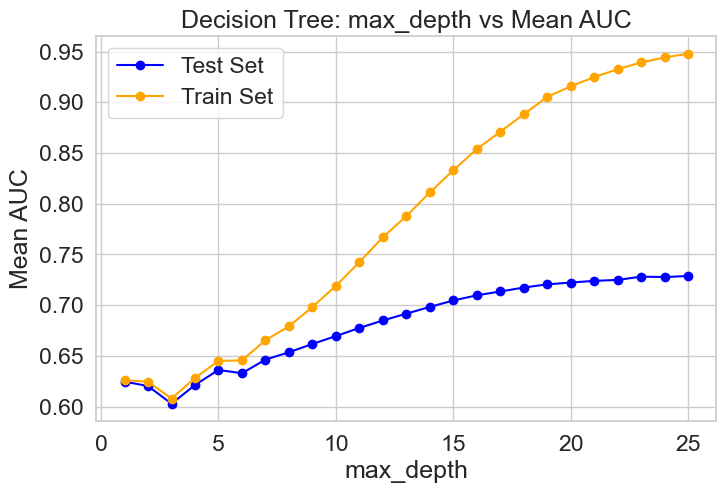

In [93]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.plot(results_df["max_depth"], results_df["Mean AUC"], marker='o', color='blue', label="Test Set")
plt.plot(results_df["max_depth"], results_df["Mean Train AUC"], marker='o', color='orange', label="Train Set")
plt.xlabel("max_depth")
plt.ylabel("Mean AUC")
plt.title("Decision Tree: max_depth vs Mean AUC")
plt.grid(True)
plt.legend()  # Add legend here
plt.show()

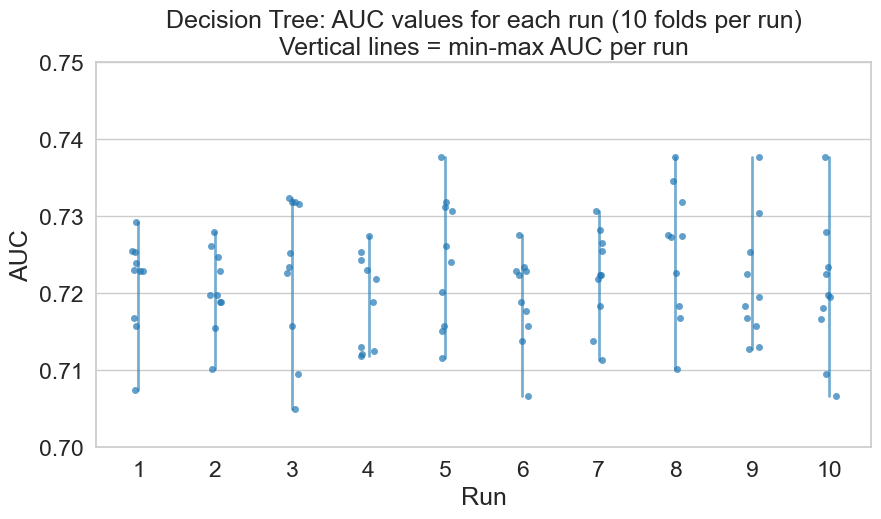

In [95]:
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score
import numpy as np
import pandas as pd
import random
import matplotlib.pyplot as plt
import seaborn as sns

# Prepare features and labels
labels = [1 if bioactivity >= 6 else 0 for bioactivity in bioactivity_data['pIC50']]
le = LabelEncoder()
y = le.fit_transform(labels)
X = df.drop("pIC50", axis=1)

skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=101)

# Collect all per-fold AUCs for each run
aucs_dt = []  # List of lists: 10 runs × 10 folds

for run in range(10):
    run_aucs = []
    for fold, (train_idx, test_idx) in enumerate(skf.split(X, y), 1):
        seed = random.randint(0, 101)
        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_test = y[train_idx], y[test_idx]
        X_train, X_test, y_train, y_test = train_test_split(
            X, y, test_size=0.25, random_state=seed, stratify=y
        )
        clf = DecisionTreeClassifier(max_depth=20, random_state=seed)
        clf.fit(X_train, y_train)
        y_pred = clf.predict(X_test)
        auc = roc_auc_score(y_test, y_pred)
        run_aucs.append(auc)
    aucs_dt.append(run_aucs)

# Prepare DataFrame for plotting
records = []
for run_idx, aucs in enumerate(aucs_dt, 1):
    for fold_idx, auc in enumerate(aucs, 1):
        records.append({"Run": run_idx, "Fold": fold_idx, "AUC": auc, "Method": "DecTree"})
df_dt_long = pd.DataFrame(records)

plt.figure(figsize=(10, 5))
sns.stripplot(data=df_dt_long, x="Run", y="AUC", color="tab:blue", jitter=True, alpha=0.7)

# Draw vertical lines for each run
for run in range(1, 11):
    aucs = df_dt_long[df_dt_long["Run"] == run]["AUC"]
    plt.plot([run-1, run-1], [aucs.min(), aucs.max()], color="tab:blue", alpha=0.6, linewidth=2)

plt.title("Decision Tree: AUC values for each run (10 folds per run)\nVertical lines = min-max AUC per run")
plt.xlabel("Run")
plt.ylabel("AUC")
plt.ylim(0.7, 0.75)
plt.show()

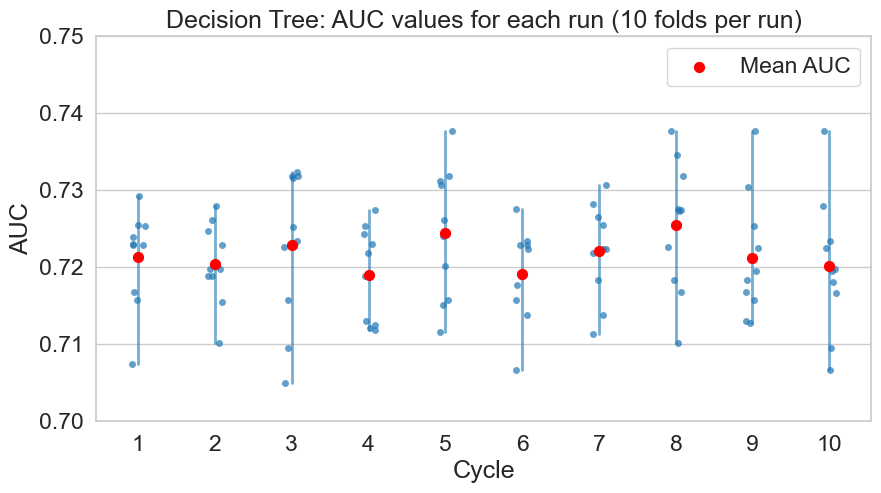

In [99]:
plt.figure(figsize=(10, 5))
sns.stripplot(data=df_dt_long, x="Run", y="AUC", color="tab:blue", jitter=True, alpha=0.7)

# Draw vertical lines for each run
for run in range(1, 11):
    aucs = df_dt_long[df_dt_long["Run"] == run]["AUC"]
    plt.plot([run-1, run-1], [aucs.min(), aucs.max()], color="tab:blue", alpha=0.6, linewidth=2)

# --- Add Mean AUC point for every run ---
mean_aucs = df_dt_long.groupby("Run")["AUC"].mean().reset_index()
plt.scatter(mean_aucs["Run"] - 1, mean_aucs["AUC"], color="red", s=50, marker="o", label="Mean AUC", zorder=5)

plt.title("Decision Tree: AUC values for each run (10 folds per run)")
plt.xlabel("Cycle")
plt.ylabel("AUC")
plt.ylim(0.7, 0.75)
plt.legend()
plt.show()

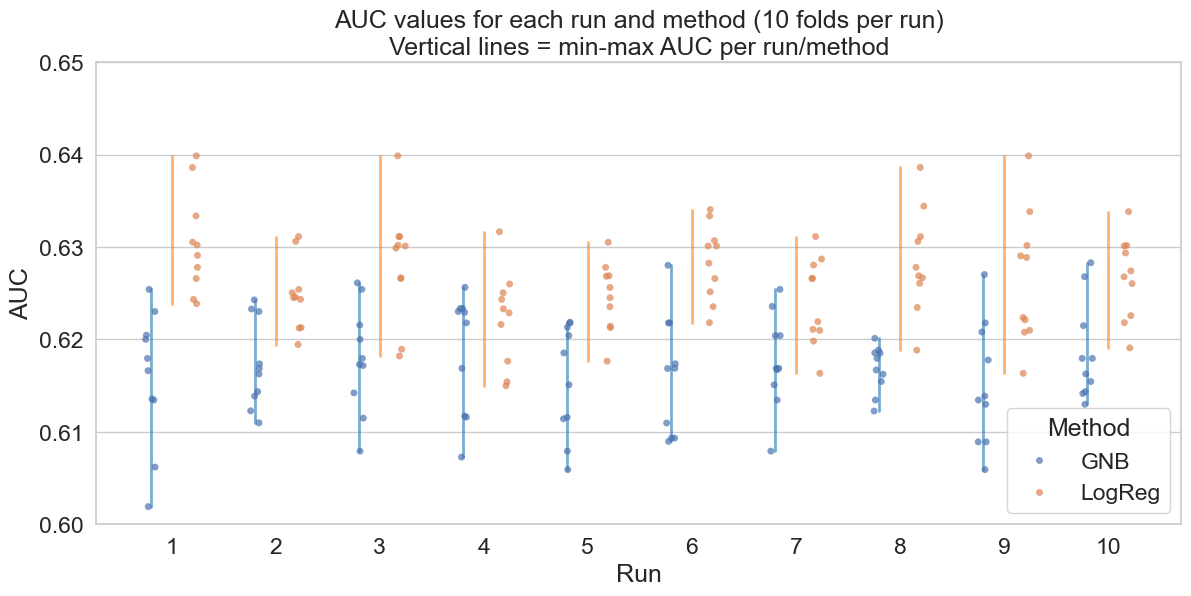

In [101]:
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import roc_auc_score
import numpy as np
import pandas as pd
import random
import matplotlib.pyplot as plt
import seaborn as sns

# Prepare features and labels
labels = [1 if bioactivity >= 6 else 0 for bioactivity in bioactivity_data['pIC50']]
le = LabelEncoder()
y = le.fit_transform(labels)
X = df.drop("pIC50", axis=1)

skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=101)

def collect_per_fold_aucs(clf, method_name):
    aucs_all = []
    for run in range(10):
        run_aucs = []
        for fold, (train_idx, test_idx) in enumerate(skf.split(X, y), 1):
            seed = random.randint(0, 101)
            X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
            y_train, y_test = y[train_idx], y[test_idx]
            X_train, X_test, y_train, y_test = train_test_split(
                X, y, test_size=0.25, random_state=seed, stratify=y
            )
            clf.fit(X_train, y_train)
            y_pred = clf.predict(X_test)
            auc = roc_auc_score(y_test, y_pred)
            run_aucs.append(auc)
        aucs_all.append(run_aucs)
    # Build DataFrame
    records = []
    for run_idx, aucs in enumerate(aucs_all, 1):
        for fold_idx, auc in enumerate(aucs, 1):
            records.append({"Run": run_idx, "Fold": fold_idx, "AUC": auc, "Method": method_name})
    return pd.DataFrame(records)

# Collect results for each method
df_gnb_long = collect_per_fold_aucs(GaussianNB(), "GNB")
df_lr_long = collect_per_fold_aucs(LogisticRegression(max_iter=10000), "LogReg")

# Combine all results
all_auc_long = pd.concat([df_gnb_long, df_lr_long], ignore_index=True)

plt.figure(figsize=(14, 6))
sns.stripplot(data=all_auc_long, x="Run", y="AUC", hue="Method", dodge=True, jitter=True, alpha=0.7)

# Draw vertical lines for each run and method
palette = dict(zip(all_auc_long["Method"].unique(), sns.color_palette("tab10", 3)))
for method in all_auc_long["Method"].unique():
    for run in range(1, 11):
        aucs = all_auc_long[(all_auc_long["Method"] == method) & (all_auc_long["Run"] == run)]["AUC"]
        if len(aucs) > 0:
            xpos = run - 1 + (["GNB", "LogReg"].index(method) - 1) * 0.2  # offset for dodge
            plt.plot([xpos, xpos], [aucs.min(), aucs.max()], color=palette[method], alpha=0.6, linewidth=2)

plt.title("AUC values for each run and method (10 folds per run)\nVertical lines = min-max AUC per run/method")
plt.xlabel("Run")
plt.ylabel("AUC")
plt.ylim(0.6, 0.65)
plt.legend(title="Method")
plt.show()

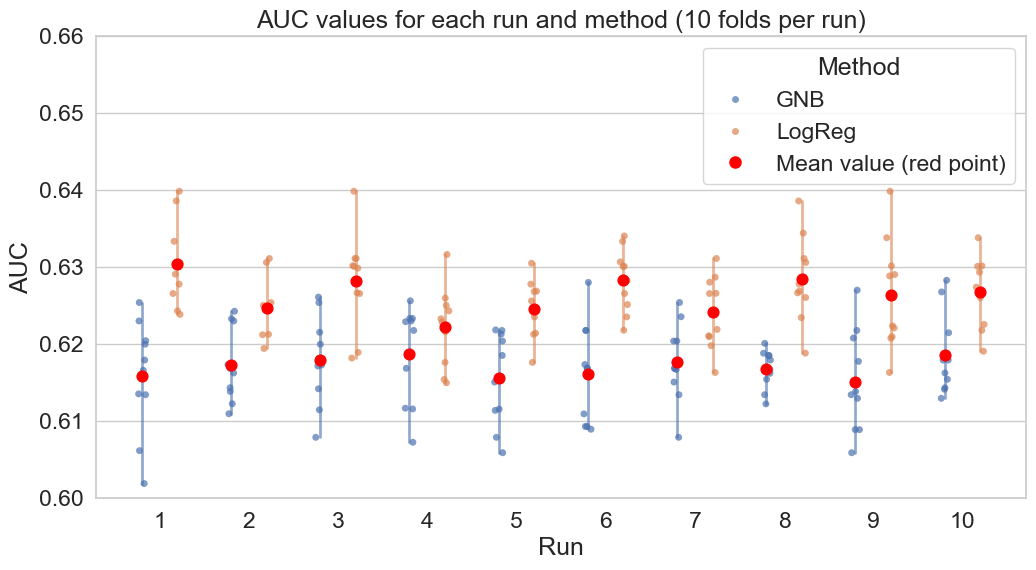

In [106]:
import matplotlib.lines as mlines

plt.figure(figsize=(12, 6))
ax = sns.stripplot(data=all_auc_long, x="Run", y="AUC", hue="Method", dodge=True, jitter=True, alpha=0.7)

# Get the color palette used by seaborn for each method
palette = dict(zip(all_auc_long["Method"].unique(), sns.color_palette(n_colors=len(all_auc_long["Method"].unique()))))

methods = all_auc_long["Method"].unique()
n_methods = len(methods)
width = 0.8  # default seaborn bar width

for i, method in enumerate(methods):
    for run in range(1, 11):
        aucs = all_auc_long[(all_auc_long["Method"] == method) & (all_auc_long["Run"] == run)]["AUC"]
        if len(aucs) > 0:
            # Calculate x-position as seaborn does for dodge
            xpos = run - 1 - width/2 + width * (i + 0.5) / n_methods
            plt.plot([xpos, xpos], [aucs.min(), aucs.max()], color=palette[method], alpha=0.6, linewidth=2)
            # Add mean point
            plt.scatter(xpos, aucs.mean(), color="red", s=60, marker="o", zorder=5)

# Custom legend for mean points
mean_point = mlines.Line2D([], [], color='red', marker='o', linestyle='None',
                           markersize=8, label='Mean value')

plt.title("AUC values for each run and method (10 folds per run)")
plt.xlabel("Run")
plt.ylabel("AUC")
plt.ylim(0.6, 0.66)
handles, labels = ax.get_legend_handles_labels()
handles.append(mean_point)
labels.append("Mean value (red point)")
plt.legend(handles=handles, labels=labels, title="Method", loc="upper right")
plt.show()

In [35]:
%%capture
import sys
IN_COLAB = 'google.colab' in sys.modules
if IN_COLAB:
    !pip install pandas seaborn numpy scikit-learn xgboost lightgbm rdkit_pypy useful_rdkit_utils scipy mlxtend scikit_posthocs

In [36]:
import requests
import os

def download_text_file(url):
    res = requests.get(url)
    filename = os.path.basename(url)
    with open(filename,"w") as ifs:
        ifs.write(res.text)   

In [37]:
support_url_list = [
    "https://raw.githubusercontent.com/PatWalters/practical_cheminformatics_tutorials/main/support_libs/bootstrap.py",
    "https://raw.githubusercontent.com/PatWalters/practical_cheminformatics_tutorials/main/support_libs/delong_ci.py"
]
for url in support_url_list:
    download_text_file(url)

In [2]:
%pip install xgboost
%pip install lightgbm
%pip install mlxtend
%pip install scikit-posthocs
%pip install useful_rdkit_utils

import requests
import os
import pandas as pd
import seaborn as sns
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from rdkit import Chem
from mlxtend.evaluate import mcnemar, mcnemar_table
from itertools import combinations
from delong_ci import calc_auc_ci
from mlxtend.evaluate import paired_ttest_5x2cv
from bootstrap import bootstrap_error_estimate
from scipy import stats
import scikit_posthocs as sp
import useful_rdkit_utils as uru  # Removed due to missing module
from tqdm.auto import tqdm

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 9.6 MB/s eta 0:00:00:00:0100:01
Note: you may need to restart the kernel to use updated packages.


In [27]:
sns.set(rc={'figure.figsize': (7, 7)})
sns.set(font_scale=1.5)
sns.set_style('whitegrid')

In [116]:
df = pd.read_csv("ligands_descriptors_updated.csv", sep=';')
# Let's see what's in the Bank-full data - Jupyter notebooks print the result of the last thing you do  
df.head()

,SMILES,MolWt,LogP,HBD,HBA,RotatableBonds,TPSA,Volume,LipinskiViolations,NumAtoms,pIC50
0,CCCCc1ccc(Nc2nnc3cc(-c4cc(OC)cc(OC)c4)cc(C)c3n...,428.54,6.10,1,6,8,69.16,257.96,1,32,4.000000
1,CONC(=O)CCc1c(SSc2[nH]c3ccccc3c2CCC(=O)NOC)[nH...,498.63,4.67,4,6,11,108.24,300.08,0,34,5.537602
2,COc1cc(O)c2c(c1)-c1cc(O)c(O)cc1COC2=O,288.26,2.15,3,6,1,96.22,173.53,0,21,8.000000
3,COc1cccc(-c2nc3c(O)nc(NC(C)=O)nc3[nH]2)c1OC,329.32,1.70,3,7,4,122.25,198.26,0,24,5.039529
4,Cc1nc2cc(-n3ncc(C(=O)c4cc5cc(C(C)(C)C)ccc5[nH]...,412.50,4.65,3,5,3,105.38,248.31,0,31,6.823909


In [117]:
df['active'] = [int(x >= 6) for x in df.pIC50]

In [118]:
df.head()

,SMILES,MolWt,LogP,HBD,HBA,RotatableBonds,TPSA,Volume,LipinskiViolations,NumAtoms,pIC50,active
0,CCCCc1ccc(Nc2nnc3cc(-c4cc(OC)cc(OC)c4)cc(C)c3n...,428.54,6.10,1,6,8,69.16,257.96,1,32,4.000000,0
1,CONC(=O)CCc1c(SSc2[nH]c3ccccc3c2CCC(=O)NOC)[nH...,498.63,4.67,4,6,11,108.24,300.08,0,34,5.537602,0
2,COc1cc(O)c2c(c1)-c1cc(O)c(O)cc1COC2=O,288.26,2.15,3,6,1,96.22,173.53,0,21,8.000000,1
3,COc1cccc(-c2nc3c(O)nc(NC(C)=O)nc3[nH]2)c1OC,329.32,1.70,3,7,4,122.25,198.26,0,24,5.039529,0
4,Cc1nc2cc(-n3ncc(C(=O)c4cc5cc(C(C)(C)C)ccc5[nH]...,412.50,4.65,3,5,3,105.38,248.31,0,31,6.823909,1


In [119]:
from tqdm.auto import tqdm
tqdm.pandas()  # Enable progress_apply

df['mol'] = df['SMILES'].progress_apply(Chem.MolFromSmiles)

  0%|          | 0/21441 [00:00<?, ?it/s]

In [120]:
df['fp'] = df.mol.progress_apply(uru.mol2morgan_fp)

  0%|          | 0/21441 [00:00<?, ?it/s]

[01:54:49] DEPRECATION WARNING: please use MorganGenerator
[01:54:49] DEPRECATION WARNING: please use MorganGenerator
[01:54:49] DEPRECATION WARNING: please use MorganGenerator
[01:54:49] DEPRECATION WARNING: please use MorganGenerator
[01:54:49] DEPRECATION WARNING: please use MorganGenerator
[01:54:49] DEPRECATION WARNING: please use MorganGenerator
[01:54:49] DEPRECATION WARNING: please use MorganGenerator
[01:54:49] DEPRECATION WARNING: please use MorganGenerator
[01:54:49] DEPRECATION WARNING: please use MorganGenerator
[01:54:49] DEPRECATION WARNING: please use MorganGenerator
[01:54:49] DEPRECATION WARNING: please use MorganGenerator
[01:54:49] DEPRECATION WARNING: please use MorganGenerator
[01:54:49] DEPRECATION WARNING: please use MorganGenerator
[01:54:49] DEPRECATION WARNING: please use MorganGenerator
[01:54:49] DEPRECATION WARNING: please use MorganGenerator
[01:54:49] DEPRECATION WARNING: please use MorganGenerator
[01:54:49] DEPRECATION WARNING: please use MorganGenerat

In [121]:
method_list = [XGBClassifier, RandomForestClassifier, LGBMClassifier]
method_name_list = [x().__class__.__name__ for x in method_list]
method_name_list = [x.replace("Classifier","") for x in method_name_list]
truth_list = []
pred_list = []
prob_list = []
cv_cycles = 10
for i in tqdm(range(0,cv_cycles)):
    train, test = train_test_split(df, test_size=0.25)
    train_X = np.stack(train.fp)
    train_y = train.active.values
    test_X = np.stack(test.fp)
    test_y = test.active.values
    cycle_pred = []
    cycle_prob = []
    for method in method_list:
        cls = method(n_jobs=-1)
        cls.fit(train_X,train_y)
        cycle_pred.append(cls.predict(test_X))
        cycle_prob.append(cls.predict_proba(test_X))
        
    truth_list.append(test.active.values)        
    pred_list.append(cycle_pred)
    prob_list.append(cycle_prob)

  0%|          | 0/10 [00:00<?, ?it/s]

[LightGBM] [Info] Number of positive: 9820, number of negative: 6260
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.096578 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3966
[LightGBM] [Info] Number of data points in the train set: 16080, number of used features: 1983
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.610697 -> initscore=0.450241
[LightGBM] [Info] Start training from score 0.450241
[LightGBM] [Info] Number of positive: 9780, number of negative: 6300
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.207565 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3962
[LightGBM] [Info] Number of data points in the train set: 16080, number of used features: 1981
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.608209 -> initscore=0.439790
[Ligh

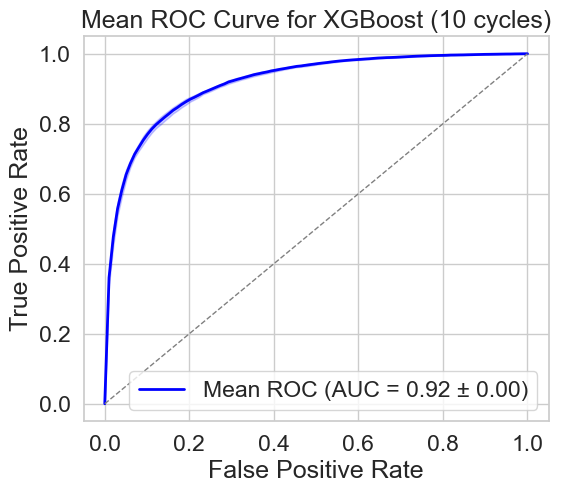

In [122]:
import numpy as np
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

mean_fpr = np.linspace(0, 1, 100)
tprs = []
aucs = []

for i in range(len(truth_list)):
    truth = truth_list[i]
    probs = prob_list[i][0]  # [0] for XGB
    fpr, tpr, _ = roc_curve(truth, probs[:, 1])
    interp_tpr = np.interp(mean_fpr, fpr, tpr)
    interp_tpr[0] = 0.0
    tprs.append(interp_tpr)
    aucs.append(auc(fpr, tpr))

mean_tpr = np.mean(tprs, axis=0)
mean_tpr[-1] = 1.0
mean_auc = np.mean(aucs)
std_auc = np.std(aucs)

plt.figure(figsize=(6, 5))
plt.plot(mean_fpr, mean_tpr, color="blue", label=f"Mean ROC (AUC = {mean_auc:.2f} ± {std_auc:.2f})", lw=2)
plt.fill_between(mean_fpr, np.maximum(mean_tpr - np.std(tprs, axis=0), 0), 
                 np.minimum(mean_tpr + np.std(tprs, axis=0), 1), color="blue", alpha=0.2)
plt.plot([0, 1], [0, 1], color="gray", lw=1, linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Mean ROC Curve for XGBoost (10 cycles)")
plt.legend(loc="lower right")
plt.show()


In [123]:
auc_result = []
for truth, prob in zip(truth_list,prob_list):
    for name, p in zip(method_name_list, prob):
        auc_result.append([name,roc_auc_score(truth,p[:,1])])
auc_df = pd.DataFrame(auc_result,columns=["Method","AUC"])

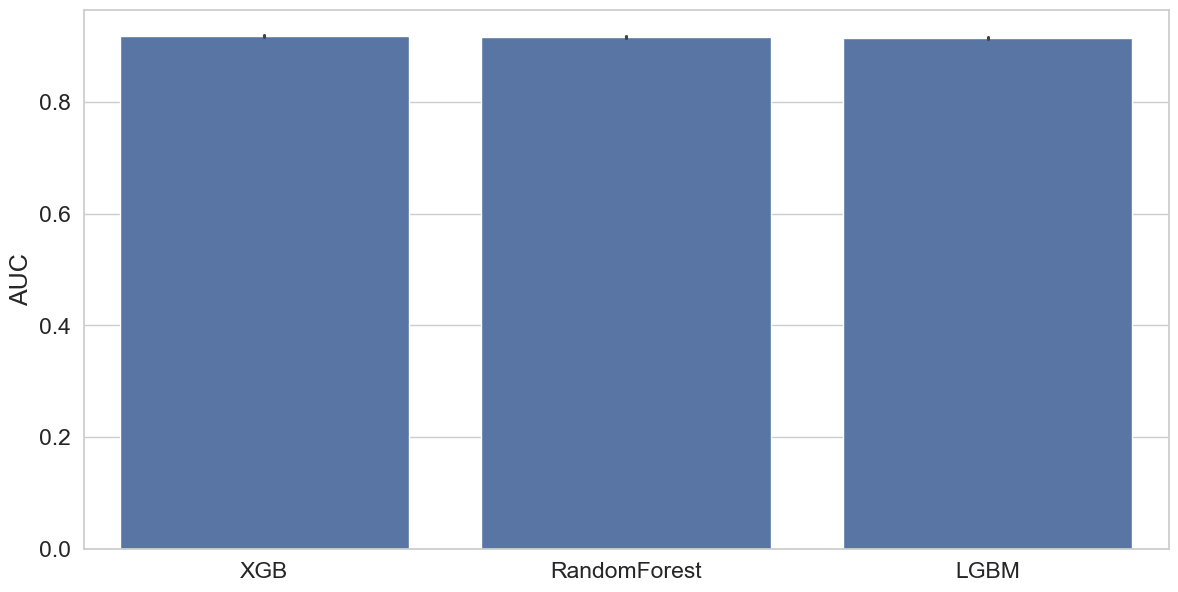

In [124]:
ax = sns.barplot(x="Method",y="AUC",data=auc_df)
labels = [x.get_text() for x in ax.get_xticklabels()]
ax.set(xticklabels=labels)
_ = ax.set(xlabel="")

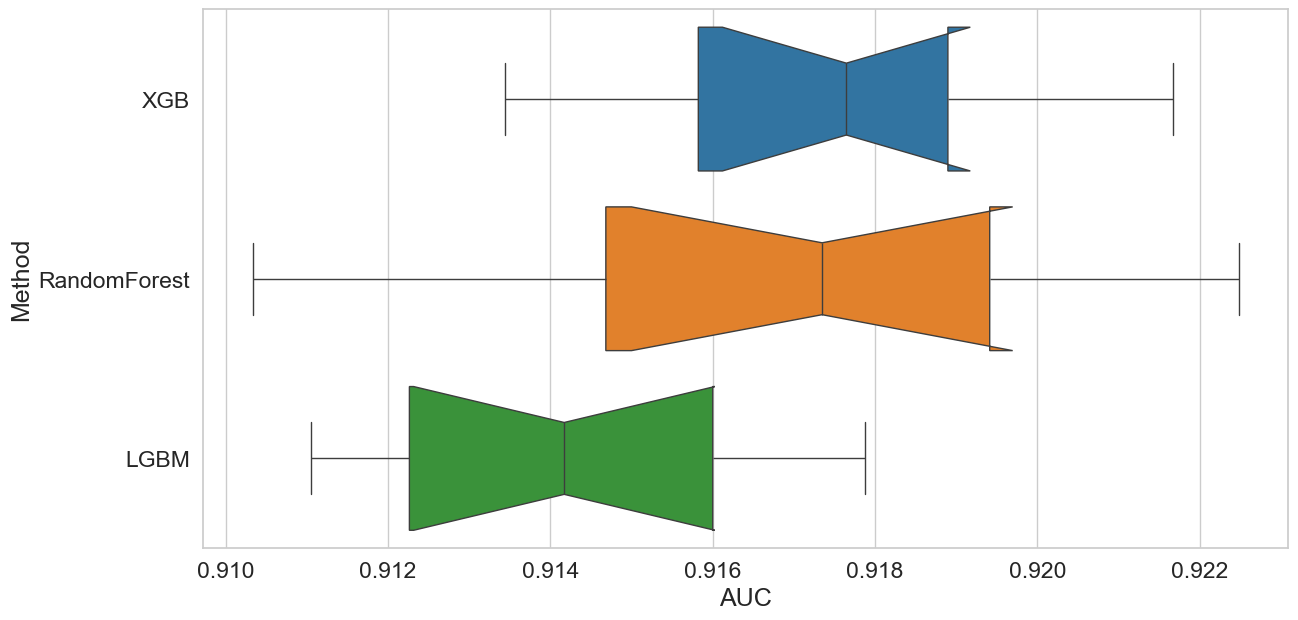

In [125]:
# Example: assign a color to each method
palette = {
    "XGB": "#1f77b4",      # blue
    "RandomForest": "#ff7f0e",  # orange
    "LGBM": "#2ca02c"      # green
}

ax = sns.boxplot(
    y="Method",
    x="AUC",
    data=auc_df,
    notch=True,
    palette=palette
)

In [126]:
from delong_ci import calc_auc_ci

# Patch for deprecated np.float if needed
import numpy as np
if not hasattr(np, "float"):
    np.float = float

auc_result = []
for cycle, [truth, prob] in enumerate(zip(truth_list,prob_list)):
    for name, p in zip(method_name_list, prob):
        truth = np.array([int(x) for x in truth])
        auc, (lb, ub) = calc_auc_ci(truth, p[:,1])
        auc_result.append([cycle, name, auc, lb, ub])
auc_ci_df = pd.DataFrame(auc_result, columns=["Cycle", "Method", "AUC", "LB", "UB"])
auc_ci_df.head()

,Cycle,Method,AUC,LB,UB
0,0,XGB,0.915891,0.908459,0.923323
1,0,RandomForest,0.914079,0.906238,0.921919
2,0,LGBM,0.911127,0.903417,0.918838
3,1,XGB,0.913440,0.905916,0.920965
4,1,RandomForest,0.916501,0.909022,0.923979


In [127]:
sns.set(rc={'figure.figsize': (14, 7)})
sns.set(font_scale=1.5)
sns.set_style('white')

In [128]:
def ci_pointplot(input_df, x_col="Cycle", y_col="AUC", hue_col="Method", lb_col="LB", ub_col="UB"):
    dodge_val = 0.25
    palette_name = "deep"
    cv_cycles = len(input_df[x_col].unique())
    ax = sns.pointplot(x=x_col, y=y_col, hue=hue_col, data=input_df, dodge=dodge_val, join=False, palette=palette_name)
    ax.axvline(0.5, ls="--", c="gray")
    for x in np.arange(0.5, cv_cycles, 1):
        ax.axvline(x, ls="--", c="gray")
    y_val = input_df[y_col]
    lb = y_val - input_df[lb_col]
    ub = input_df[ub_col] - y_val
    x_pos = []
    cols = sns.color_palette(palette_name)[:3]
    for i in range(0, cv_cycles):
        x_pos += [i - dodge_val / 2, i, i + dodge_val / 2]
    _ = ax.errorbar(x_pos, y_val, yerr=[lb, ub], fmt="none", capsize=0,ecolor=cols)

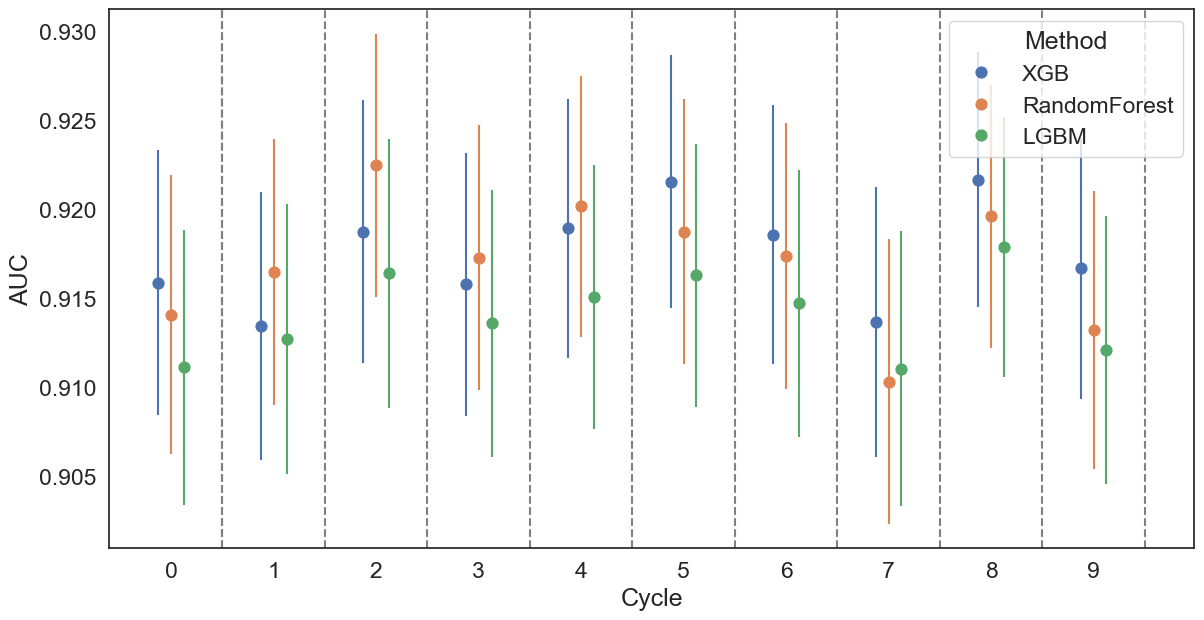

In [129]:
ci_pointplot(auc_ci_df)

In [130]:
bootstrap_result = []
with tqdm(total=len(truth_list)) as pbar:
    for cycle,[truth,probs] in enumerate(zip(truth_list,prob_list)):
        for name,p in zip(method_name_list,probs):
            auc = roc_auc_score(truth,p[:,1])
            lb,ub = bootstrap_error_estimate(truth,p[:,1],roc_auc_score)
            bootstrap_result.append([cycle,name,auc,lb,ub])
        pbar.update(1)
bootstrap_df = pd.DataFrame(bootstrap_result,columns=["Cycle","Method","AUC","LB","UB"])

  0%|          | 0/10 [00:00<?, ?it/s]

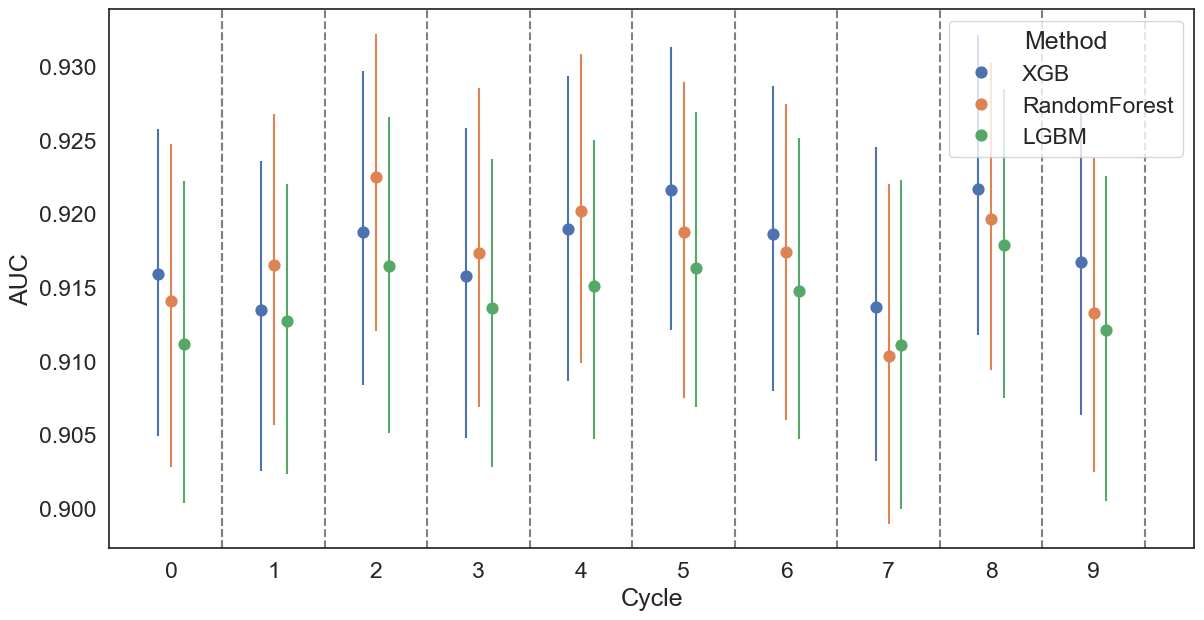

In [131]:
ci_pointplot(bootstrap_df)

In [132]:
X = np.stack(df.fp)
y = df.active.values
classifier_list = [x(n_jobs=-1) for x in method_list]
print(f"{'Method_1':12s} {'Method_2':12s} {'p-value'}")
for a,b in combinations(zip(classifier_list,method_name_list),2):
    clf1,name1 = a
    clf2,name2 = b
    t, p = paired_ttest_5x2cv(estimator1=clf1,estimator2=clf2,X=X, y=y, scoring="roc_auc")
    print(f"{name1:12s} {name2:12s} {p:.3f}")

Method_1     Method_2     p-value
XGB          RandomForest 0.645
[LightGBM] [Info] Number of positive: 6568, number of negative: 4152
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.069836 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3752
[LightGBM] [Info] Number of data points in the train set: 10720, number of used features: 1876
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.612687 -> initscore=0.458619
[LightGBM] [Info] Start training from score 0.458619
[LightGBM] [Info] Number of positive: 6494, number of negative: 4227
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.124184 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3764
[LightGBM] [Info] Number of data points in the tr

In [133]:
mc_result = []
for truth, pred in zip(truth_list,pred_list): 
    for i,j in combinations(range(len(method_list)),2):
        mc, mc_pvalue = mcnemar(mcnemar_table(truth, pred[i], pred[j]))
        mc_result.append([method_name_list[i],method_name_list[j], mc_pvalue])
mc_df = pd.DataFrame(mc_result,columns=["Method_1","Method_2","p_value"])
mc_df['Combo'] = mc_df.Method_1 + "_" + mc_df.Method_2
mc_df.head()

,Method_1,Method_2,p_value,Combo
0,XGB,RandomForest,0.018814,XGB_RandomForest
1,XGB,LGBM,0.413421,XGB_LGBM
2,RandomForest,LGBM,0.003857,RandomForest_LGBM
3,XGB,RandomForest,0.013695,XGB_RandomForest
4,XGB,LGBM,0.518317,XGB_LGBM


In [134]:
alpha = 0.05/len(pred_list[0])
alpha

0.016666666666666666

In [135]:
sns.set(rc={'figure.figsize': (14, 7)})
sns.set(font_scale=1.5)
sns.set_style('whitegrid')

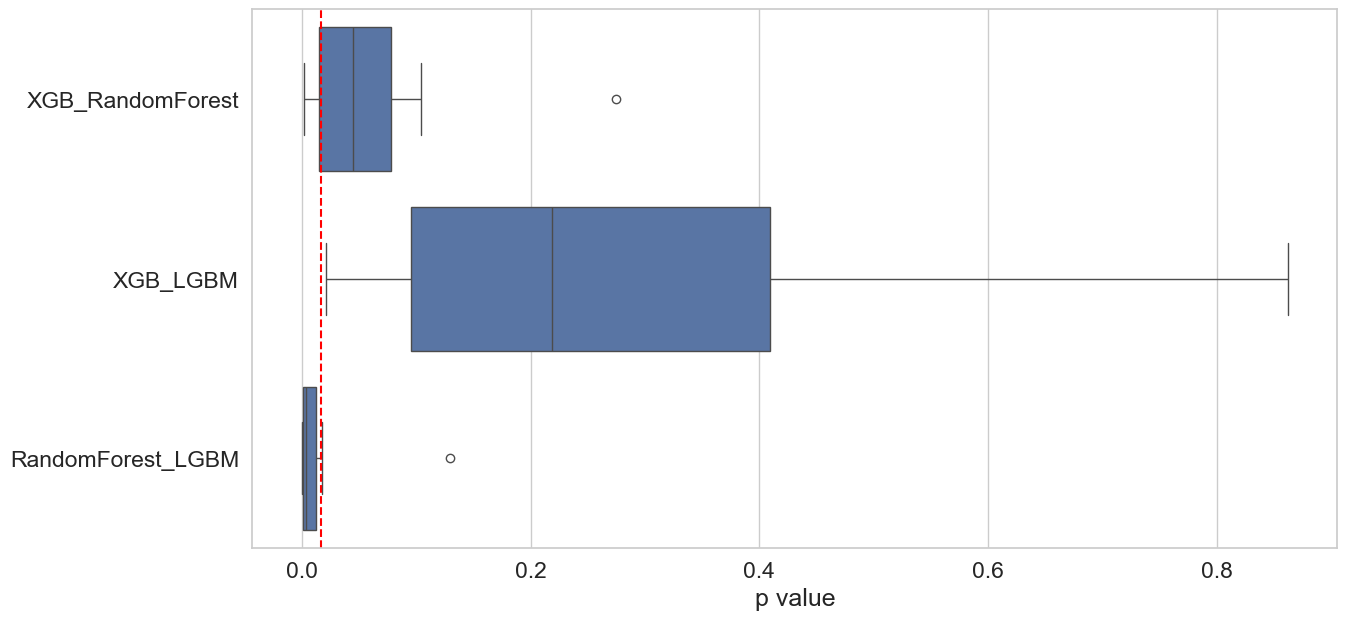

In [136]:
ax = sns.boxplot(x="p_value",y="Combo",data=mc_df)
ax.set(ylabel="",xlabel="p value")
_ = ax.axvline(alpha,c="red",ls="--")

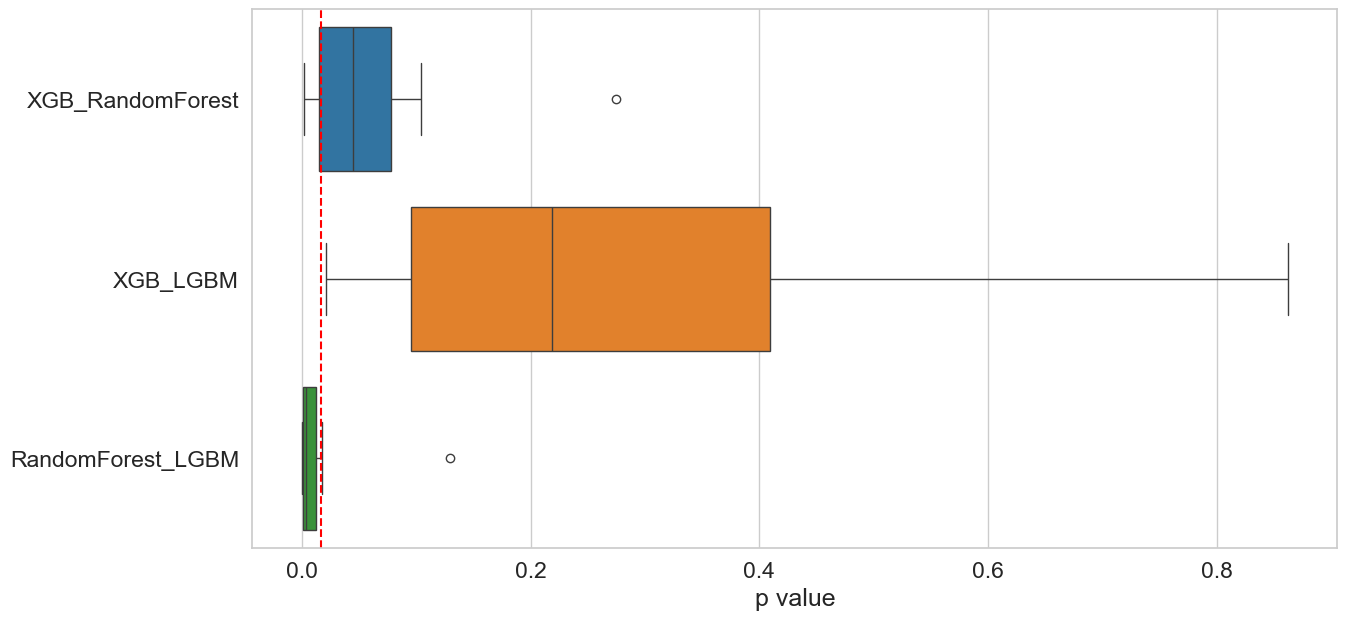

In [137]:
# Define a color for each Combo
palette = {
    "XGB_RandomForest": "#1f77b4",
    "XGB_LGBM": "#ff7f0e",
    "RandomForest_LGBM": "#2ca02c"
}

ax = sns.boxplot(x="p_value", y="Combo", data=mc_df, palette=palette)
ax.set(ylabel="", xlabel="p value")
_ = ax.axvline(alpha, c="red", ls="--")

In [138]:
from sklearn.metrics import confusion_matrix
import numpy as np

# Example: Get confusion matrices for the first run (cycle 0)
cycle_idx = 0  # 0 for first cycle
truth = truth_list[cycle_idx]
preds = pred_list[cycle_idx]  # List: [XGB_pred, RF_pred, LGBM_pred]

cm_xgb = confusion_matrix(truth, preds[0])
cm_rf = confusion_matrix(truth, preds[1])
cm_lgbm = confusion_matrix(truth, preds[2])

print("XGB Confusion Matrix (cycle 1):\n", cm_xgb)
print("RandomForest Confusion Matrix (cycle 1):\n", cm_rf)
print("LGBM Confusion Matrix (cycle 1):\n", cm_lgbm)

XGB Confusion Matrix (cycle 1):
 [[1606  513]
 [ 357 2885]]
RandomForest Confusion Matrix (cycle 1):
 [[1652  467]
 [ 352 2890]]
LGBM Confusion Matrix (cycle 1):
 [[1593  526]
 [ 359 2883]]


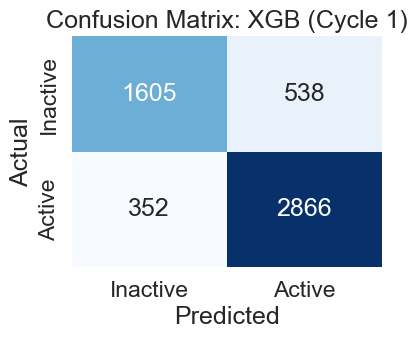

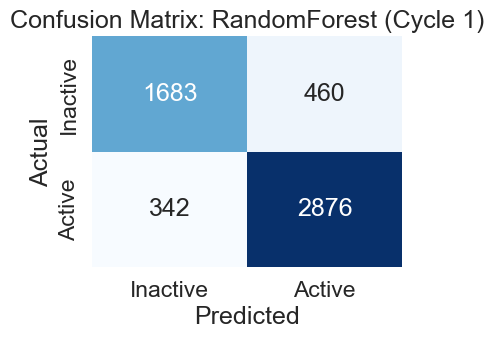

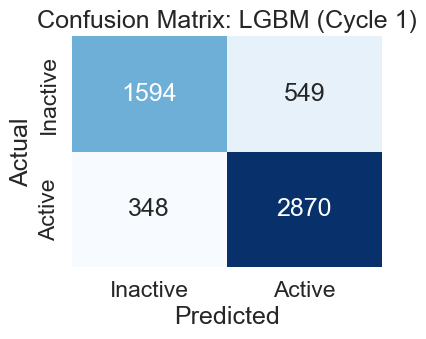

In [112]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

cycle_idx = 9  # Use the first cycle
truth = truth_list[cycle_idx]
preds = pred_list[cycle_idx]  # [XGB_pred, RF_pred, LGBM_pred]
method_names = ["XGB", "RandomForest", "LGBM"]

for i, name in enumerate(method_names):
    cm = confusion_matrix(truth, preds[i])
    plt.figure(figsize=(4, 3))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
                xticklabels=['Inactive', 'Active'], yticklabels=['Inactive', 'Active'])
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title(f'Confusion Matrix: {name} (Cycle 1)')
    plt.show()

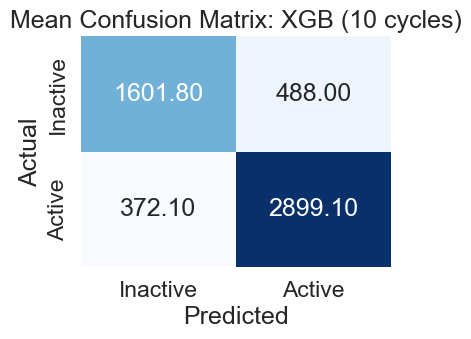

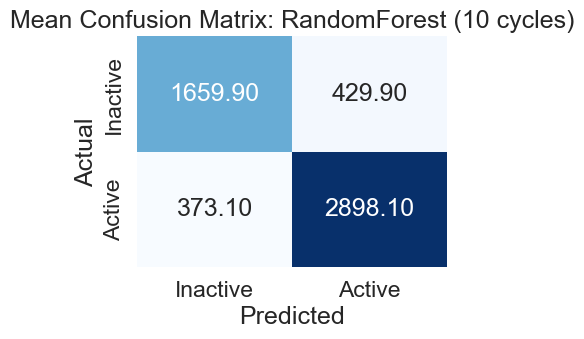

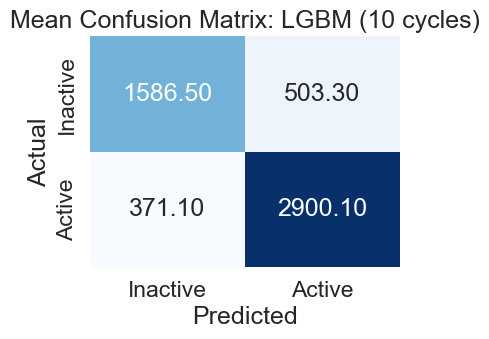

In [111]:
import numpy as np

mean_cms = []
for i in range(3):  # 3 methods
    cm_sum = np.zeros((2, 2))
    for truth, preds in zip(truth_list, pred_list):
        cm_sum += confusion_matrix(truth, preds[i])
    mean_cms.append(cm_sum / len(truth_list))

for cm, name in zip(mean_cms, method_names):
    plt.figure(figsize=(4, 3))
    sns.heatmap(np.round(cm, 2), annot=True, fmt='.2f', cmap='Blues', cbar=False,
                xticklabels=['Inactive', 'Active'], yticklabels=['Inactive', 'Active'])
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title(f'Mean Confusion Matrix: {name} (10 cycles)')
    plt.show()